
# Pipeline A — Interactive Walkthrough

Runs the predictive semantic cache invalidation pipeline (`parser -> embedder ->
extractor -> predictor -> evaluator -> visualizer`) one stage at a time, timing
every stage and sub-step, and showing intermediate results as it goes.

This mirrors the orchestration in `run_experiment.py`'s `Experiment` class, but
each stage is its own cell so you can inspect, re-run, or tweak any single part
without re-running the whole pipeline. It skips `run_experiment.py`'s
per-commit-pair diagnostic JSON dumping (that's for post-hoc debugging, not
needed to see how the pipeline behaves here).

**How to use:** set the config in the next cell, then run all cells top to
bottom. The last section shows a full timing breakdown (which stage/sub-step
took the most time) and a table of every result produced along the way.


In [3]:
# =============================================================================
# SETTINGS — everything you'd normally pass as CLI flags / settings.json
# =============================================================================

CONFIG = {
    "repo_url":        "https://github.com/psf/black.git",
    "workspace_dir":   "workspace",
    "model_name":      "sentence-transformers/all-MiniLM-L6-v2",
    "device":          "cuda",  # "auto" (CUDA if available, else CPU), "cpu", "cuda", "cuda:0", ...

    "num_commits":     150,    # number of sampled commits to analyze
    "commit_stride":   15,     # step size between sampled commits
    "train_ratio":     0.7,    # fraction of commits used for training

    "threshold":       0.05,   # drift threshold for classification (ignored when threshold_mode="dynamic")
    "threshold_mode":  "dynamic",   # "fixed" or "dynamic" (85th percentile of train drift)

    "clean_mode":       False,  # strip comments/docstrings before embedding
    "context_chunking": True,   # splice dependency stubs into embedded source

    "k_values":          [5, 10],   # Recall@K values to evaluate
    "fixed_hop_values":  [1, 2],    # K values for the fixed-hop baseline
}

RANDOM_SEED = 42

## Setup — imports, timing infrastructure, and the execution plan

In [4]:
import sys, os, time, json, logging, warnings
from pathlib import Path
from contextlib import contextmanager
from typing import Dict, List, Set, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from parser.git_helper import GitHelper
from parser.tree_sitter_repo_parser import TreeSitterRepoParser, Entity
from embedder.embedding_manager import EmbeddingManager
from extractor.feature_extractor import FeatureExtractor
from extractor.gtd import GraphTransitionDescriptor
from extractor.rsd import RepositoryStateDescriptor
from predictor.predictor import DriftPredictor, train_test_split_temporal
from evaluator.evaluator import (
    Evaluator, BaselineAChangedOnly, BaselineBFullReindex, BaselineCFixedHop,
    BaselineDPageRankPropagation, PredictiveStrategy, WeightedBFSDecayStrategy,
)
from visualizer.visualize import Visualizer

logging.basicConfig(level=logging.WARNING)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

# Recall@K column names derived from CONFIG["k_values"] — never hardcode
# "recall_at_10" downstream, since k_values is meant to be changed above.
RECALL_COLS = [f"recall_at_{k}" for k in CONFIG["k_values"]]
PRIMARY_RECALL_COL = f"recall_at_{max(CONFIG['k_values'])}"


# ---- Timing infrastructure -------------------------------------------------
TIMINGS: List[dict] = []  # rows of {stage, substage, seconds}


@contextmanager
def timed(stage: str, substage: str = "_total"):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        TIMINGS.append({"stage": stage, "substage": substage,
                         "seconds": time.perf_counter() - t0})


def timing_table(group_cols=("stage", "substage")) -> pd.DataFrame:
    if not TIMINGS:
        return pd.DataFrame(columns=[*group_cols, "calls", "total_seconds", "mean_seconds"])
    df = pd.DataFrame(TIMINGS)
    g = df.groupby(list(group_cols), sort=False)["seconds"].agg(["count", "sum", "mean"]).reset_index()
    g.columns = [*group_cols, "calls", "total_seconds", "mean_seconds"]
    return g.sort_values("total_seconds", ascending=False).reset_index(drop=True)


# ---- The plan ---------------------------------------------------------------
PLAN = [
    ("0. Setup",              "Clone repo, construct embedder/predictor/visualizer"),
    ("1. Harvest commits",    "Read commit history, pick sampled commits at the given stride"),
    ("2. Parse & embed",      "Per sampled commit: checkout, Tree-sitter parse, batch-embed entities"),
    ("3. Drift & features",   "Per consecutive commit pair: compute drift, GTD, modified entities, features"),
    ("4. Train predictor",    "Fit the drift classifier on training commit pairs, evaluate on held-out split"),
    ("5. Evaluate strategies","Per test commit pair: predict drift, score every cache-invalidation strategy"),
    ("6. Visualize",          "Render plots + summary report from everything collected above"),
]
print("Execution plan:")
for i, (stage, desc) in enumerate(PLAN):
    print(f"  {stage:<24s} {desc}")

Execution plan:
  0. Setup                 Clone repo, construct embedder/predictor/visualizer
  1. Harvest commits       Read commit history, pick sampled commits at the given stride
  2. Parse & embed         Per sampled commit: checkout, Tree-sitter parse, batch-embed entities
  3. Drift & features      Per consecutive commit pair: compute drift, GTD, modified entities, features
  4. Train predictor       Fit the drift classifier on training commit pairs, evaluate on held-out split
  5. Evaluate strategies   Per test commit pair: predict drift, score every cache-invalidation strategy
  6. Visualize             Render plots + summary report from everything collected above


## Stage 0 — Setup: clone repository, construct pipeline components

In [5]:
with timed("0_setup", "clone_repo"):
    repo_path = PROJECT_ROOT / CONFIG["workspace_dir"] / "black"
    git_helper = GitHelper(str(repo_path))
    ok = git_helper.clone_repo(CONFIG["repo_url"], str(repo_path))
    assert ok, "Failed to clone repository"

with timed("0_setup", "construct_components"):
    embedding_manager = EmbeddingManager(model_name=CONFIG["model_name"], clean_mode=CONFIG["clean_mode"],
                                          device=CONFIG["device"])
    predictor = DriftPredictor(model_type="random_forest", task_type="classification",
                                threshold=CONFIG["threshold"])
    rsd = RepositoryStateDescriptor()

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    results_dir = PROJECT_ROOT / "results" / f"notebook_{timestamp}"
    results_dir.mkdir(parents=True, exist_ok=True)
    visualizer = Visualizer(str(results_dir))

print(f"Repo ready at: {repo_path}")
print(f"Results will be saved under: {results_dir}")
print(f"CUDA available: {torch.cuda.is_available()}"
      + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"Embedding device resolved to: {embedding_manager.device}")

Repo ready at: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\workspace\black
Results will be saved under: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\results\notebook_20260904_175006
CUDA available: True  (NVIDIA GeForce RTX 3050 Laptop GPU)
Embedding device resolved to: cuda


## Stage 1 — Harvest commit history

In [6]:
with timed("1_harvest", "get_commit_history"):
    raw_commit_count = CONFIG["num_commits"] * CONFIG["commit_stride"]
    all_commits = git_helper.get_commit_history(count=raw_commit_count)

assert len(all_commits) >= CONFIG["commit_stride"] + 1, (
    f"Not enough commits ({len(all_commits)}) for stride={CONFIG['commit_stride']}"
)

sampled_commits = all_commits[::CONFIG["commit_stride"]][:CONFIG["num_commits"]]
assert len(sampled_commits) >= 2, "Need at least 2 sampled commits"

print(f"Raw commits fetched: {len(all_commits)}")
print(f"Sampled commits ({len(sampled_commits)}) at stride={CONFIG['commit_stride']}:")
for c in sampled_commits:
    print(f"  {c[:10]}")

Raw commits fetched: 2250
Sampled commits (150) at stride=15:
  be563a4748
  611737f9cc
  17b22642f5
  65c52a655f
  c4a477bc69
  dc32757bcc
  15d5e36ea3
  2e52a2b3ec
  b62bd4de75
  cfb003f51c
  21c8dc85f5
  5a47fd13cc
  180bc06ede
  07b1b2f3dd
  608019dffb
  1aa14c5db0
  f3ea58cbc7
  fac4cf995c
  d240ca25ea
  013cb2b374
  df965b0558
  0bf683a659
  975ca9cefc
  25d24a10a4
  52da1f08da
  fe24a15b84
  36d3c516d3
  d00eac9944
  ba64fc757c
  06004cd319
  448885b256
  1bbb01b854
  eb5f84eb8c
  c4d2db4323
  57ab909bde
  4bcae4cf83
  58fd7885cd
  23fec8b0f7
  b69bce860c
  bbe5ae70c1
  e44e0a6598
  544ea9c217
  6695fd892f
  4501f22fcb
  a2408b3cb2
  b2c13de490
  2c5041cfa0
  788268bc39
  89b776678a
  573b8de544
  6dddbd7241
  e6cd10e761
  e7ddcb8686
  e8aadedd97
  97b8496d67
  e1c86f987e
  5d33f20a2a
  e4003c2c43
  eee949e286
  807a65f9d5
  267bc5dde9
  06ccb88bf2
  b8450b9fae
  009a17739d
  6380b9f2f6
  e2fd914dc1
  756177a617
  ef7c45f281
  79575f3376
  0fd353f163
  92eeacc2e3
  3cb010ec8e
  

## Stage 2 — Parse & embed each sampled commit

For every sampled commit: checkout, rebuild the Tree-sitter dependency graph,
and batch-generate embeddings for every entity (optionally splicing in
call-graph context per `context_chunking`).

In [7]:
def extract_signature(entity: Entity) -> str:
    # Grab just the def/class header line(s) from an entity's source.
    lines = entity.source_code.splitlines()
    def_idx = next((i for i, l in enumerate(lines)
                     if l.strip().startswith(("def ", "async def ", "class "))), -1)
    if def_idx == -1:
        return f"def {entity.entity_id.split('::')[-1]}()"
    sig_lines = []
    for i in range(def_idx, len(lines)):
        sig_lines.append(lines[i])
        if lines[i].split('#')[0].rstrip().endswith(':'):
            return "\n".join(sig_lines)
    return lines[def_idx]


def contextual_source(entity: Entity, repo_parser: TreeSitterRepoParser) -> str:
    # Entity source + one-hop dependency stubs, when context_chunking is on.
    source = entity.source_code
    if not CONFIG["context_chunking"]:
        return source

    deps = {d for d in repo_parser.get_dependencies(entity.entity_id, max_hops=1)
            if d != entity.entity_id}
    if not deps:
        return source

    stubs = []
    for dep_id in sorted(deps):
        dep = repo_parser.get_entity(dep_id)
        if not dep:
            continue
        sig = extract_signature(dep).strip()
        if not sig.endswith(':'):
            sig += ':'
        body_lines = [l.strip() for l in dep.source_code.split('\n')
                      if l.strip() and not l.strip().startswith(('def ', 'class ', '@'))]
        first_line = (body_lines[0] if body_lines else 'pass')[:120]
        stubs.append(f"{sig}\n    # Context: {first_line}\n    pass")

    return source + "\n\n# Call Graph Context\n" + "\n\n".join(stubs) if stubs else source


parsers_history: Dict[str, TreeSitterRepoParser] = {}
embeddings_history: Dict[str, Dict[str, np.ndarray]] = {}
commit_stats = []

for i, commit in enumerate(sampled_commits):
    print(f"[{i+1}/{len(sampled_commits)}] {commit[:10]}", end="  ")

    with timed("2_parse_embed", "checkout"):
        ok = git_helper.checkout_commit(commit)
    if not ok:
        print("checkout FAILED, skipping")
        continue

    with timed("2_parse_embed", "parse"):
        repo_parser = TreeSitterRepoParser(str(repo_path))
        repo_parser.parse_directory(str(repo_path))
        parsers_history[commit] = repo_parser

    entities = repo_parser.get_all_entities()
    entity_sources = {e.entity_id: contextual_source(e, repo_parser) for e in entities}

    with timed("2_parse_embed", "embed"):
        embeddings = embedding_manager.generate_embeddings_batch(entity_sources) if entity_sources else {}
    embeddings_history[commit] = embeddings

    with timed("2_parse_embed", "rsd_add_commit"):
        rsd.add_commit(commit_hash=commit, repo_parser=repo_parser, embeddings=embeddings,
                        modification_history={}, previous_drifts={},
                        commit_index=i, total_commits=len(sampled_commits))

    print(f"entities={len(entities)}  embeddings={len(embeddings)}")
    commit_stats.append({"commit": commit[:10], "n_entities": len(entities), "n_embeddings": len(embeddings)})

pd.DataFrame(commit_stats)

[1/150] be563a4748  

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

entities=252  embeddings=252
[2/150] 611737f9cc  

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=700  embeddings=700
[150/150] 40d4160f1f  

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=704  embeddings=704


,commit,n_entities,n_embeddings
0,be563a4748,252,252
1,611737f9cc,255,255
2,17b22642f5,258,258
3,65c52a655f,264,264
4,c4a477bc69,263,263
...,...,...,...
145,177744ee91,690,690
146,56ba38a484,691,691
147,42ed836d80,699,699
148,18684ccb3e,700,700


## Stage 3 — Compute drift & extract features for each consecutive commit pair

For each `(commit_a, commit_b)` pair: cosine drift between embeddings, the
Graph Transition Descriptor, which entities were *semantically* modified (an
AST-normalization filter drops purely cosmetic diffs), and the full feature
matrix fed to the predictor.

In [8]:
import ast, re as _re


def normalize_source(code_str: str) -> str:
    # AST-normalize source so cosmetic-only diffs (whitespace/comments) don't count as changes.
    try:
        return ast.dump(ast.parse(code_str), annotate_fields=False)
    except Exception:
        cleaned = _re.sub(r'#.*', '', code_str)
        return " ".join(cleaned.split())


modification_history: Dict[str, List[str]] = {}
previous_drifts: Dict[str, float] = {}
gtd_history: Dict[Tuple[str, str], GraphTransitionDescriptor] = {}
drifts_history: Dict[Tuple[str, str], Dict[str, float]] = {}
features_history: Dict[Tuple[str, str], pd.DataFrame] = {}
pair_stats = []

for i in range(1, len(sampled_commits)):
    commit_a, commit_b = sampled_commits[i - 1], sampled_commits[i]
    if commit_a not in embeddings_history or commit_b not in embeddings_history:
        continue
    emb_a, emb_b = embeddings_history[commit_a], embeddings_history[commit_b]
    if not emb_a or not emb_b:
        continue

    repo_parser_b = parsers_history[commit_b]

    with timed("3_drift_features", "compute_drift"):
        drifts = embedding_manager.compute_all_drifts(emb_a, emb_b)

    with timed("3_drift_features", "gtd"):
        gtd = GraphTransitionDescriptor()
        gtd.compute(parser_a=parsers_history.get(commit_a), parser_b=repo_parser_b, drifts=drifts)
        gtd_history[(commit_a, commit_b)] = gtd

    with timed("3_drift_features", "modified_entities"):
        modified_files = git_helper.get_modified_files(commit_a, commit_b)
        candidate_modified = {
            eid for eid in drifts
            if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
        }
        for e in repo_parser_b.get_all_entities():
            if e.file_path in modified_files:
                candidate_modified.add(e.entity_id)

        parser_prev = parsers_history.get(commit_a)
        modified_entities = set()
        for eid in candidate_modified:
            prev_e = parser_prev.entities.get(eid) if parser_prev else None
            curr_e = repo_parser_b.entities.get(eid)
            if not prev_e or not curr_e:
                modified_entities.add(eid)
            elif normalize_source(prev_e.source_code) != normalize_source(curr_e.source_code):
                modified_entities.add(eid)

    entity_ids = [eid for eid in drifts if eid in repo_parser_b.get_graph()]
    if not entity_ids:
        continue

    with timed("3_drift_features", "extract_features"):
        feature_extractor = FeatureExtractor(repo_parser_b)
        features_df = feature_extractor.extract_features_batch(
            entity_ids, commit_a, commit_b, modified_entities,
            modification_history, previous_drifts, git_helper, gtd=gtd,
        )

    for eid in modified_entities:
        feature_extractor.update_modification_history(eid, commit_b, modification_history)
    previous_drifts.update(drifts)

    drifts_history[(commit_a, commit_b)] = drifts
    features_history[(commit_a, commit_b)] = features_df

    pair_stats.append({
        "pair": f"{commit_a[:8]}->{commit_b[:8]}",
        "n_entities": len(drifts),
        "n_modified": len(modified_entities),
        "mean_drift": float(np.mean(list(drifts.values()))) if drifts else 0.0,
    })
    print(f"{commit_a[:8]}->{commit_b[:8]}  entities={len(drifts)}  modified={len(modified_entities)}")

pd.DataFrame(pair_stats)

be563a47->611737f9  entities=252  modified=3
611737f9->17b22642  entities=250  modified=81
17b22642->65c52a65  entities=258  modified=19
65c52a65->c4a477bc  entities=263  modified=12
c4a477bc->dc32757b  entities=263  modified=24
dc32757b->15d5e36e  entities=270  modified=18
15d5e36e->2e52a2b3  entities=275  modified=14
2e52a2b3->b62bd4de  entities=279  modified=17
b62bd4de->cfb003f5  entities=282  modified=16
cfb003f5->21c8dc85  entities=287  modified=20
21c8dc85->5a47fd13  entities=290  modified=22
5a47fd13->180bc06e  entities=296  modified=17
180bc06e->07b1b2f3  entities=300  modified=20
07b1b2f3->608019df  entities=299  modified=17
608019df->1aa14c5d  entities=301  modified=8
1aa14c5d->f3ea58cb  entities=302  modified=20
f3ea58cb->fac4cf99  entities=308  modified=9
fac4cf99->d240ca25  entities=310  modified=4
d240ca25->013cb2b3  entities=310  modified=22
013cb2b3->df965b05  entities=301  modified=21
df965b05->0bf683a6  entities=307  modified=13
0bf683a6->975ca9ce  entities=310  modi

,pair,n_entities,n_modified,mean_drift
0,be563a47->611737f9,252,3,-4.659569e-08
1,611737f9->17b22642,250,81,1.190801e-02
2,17b22642->65c52a65,258,19,4.066429e-03
3,65c52a65->c4a477bc,263,12,2.300880e-03
4,c4a477bc->dc32757b,263,24,1.693644e-03
...,...,...,...,...
144,cb8cddd3->177744ee,683,37,1.525895e-03
145,177744ee->56ba38a4,690,16,1.099826e-03
146,56ba38a4->42ed836d,691,31,2.722671e-03
147,42ed836d->18684ccb,699,18,3.943749e-04


## Finalize RSD & chronological train/test split

In [9]:
with timed("3_drift_features", "finalize_rsd_split"):
    rsd.build_all_rsds()
    split_idx = max(1, int(len(sampled_commits) * CONFIG["train_ratio"]))
    train_commits = sampled_commits[:split_idx]
    test_commits = sampled_commits[split_idx:]

print(f"Train commits: {len(train_commits)}   Test commits: {len(test_commits)}")
print()
print(rsd.summary_table())

Train commits: 105   Test commits: 45

Commit      S       T       M       C       E     
--------------------------------------------------
be563a47    0.3286  0.3315  0.0016  0.2287  0.0004
611737f9    0.3279  0.3291  0.0016  0.2262  0.0004
17b22642    0.3386  0.3219  0.0016  0.2393  0.0004
65c52a65    0.3417  0.3182  0.0015  0.2477  0.0004
c4a477bc    0.3422  0.3195  0.0018  0.2469  0.0004
dc32757b    0.3450  0.3243  0.0017  0.2641  0.0004
15d5e36e    0.3447  0.2946  0.0012  0.2701  0.0004
2e52a2b3    0.3445  0.2926  0.0014  0.2678  0.0004
b62bd4de    0.3465  0.2937  0.0014  0.2734  0.0004
cfb003f5    0.3473  0.3027  0.0014  0.2748  0.0004
21c8dc85    0.3488  0.3008  0.0016  0.2778  0.0004
5a47fd13    0.3509  0.3083  0.0013  0.2850  0.0005
180bc06e    0.3537  0.3170  0.0014  0.2908  0.0005
07b1b2f3    0.3571  0.3148  0.0016  0.2944  0.0005
608019df    0.3579  0.3148  0.0015  0.2936  0.0005
1aa14c5d    0.3593  0.3145  0.0015  0.2956  0.0005
f3ea58cb    0.3599  0.3240  0.0014  0.2982 

## Stage 4 — Train the drift predictor

In [10]:
with timed("4_train", "combine_training_data"):
    all_features, all_drifts = [], {}
    for i in range(1, len(train_commits)):
        key = (train_commits[i - 1], train_commits[i])
        if key not in features_history or key not in drifts_history:
            continue
        prefix = f"{key[0][:8]}_{key[1][:8]}"
        fdf = features_history[key].copy()
        fdf.index = [f"{prefix}::{eid}" for eid in fdf.index]
        all_features.append(fdf)
        all_drifts.update({f"{prefix}::{eid}": d for eid, d in drifts_history[key].items()})

    assert all_features, "No training data — widen num_commits/commit_stride"
    combined_features = pd.concat(all_features, ignore_index=False)
    combined_features = combined_features[~combined_features.index.duplicated(keep="first")]

threshold = CONFIG["threshold"]
if CONFIG["threshold_mode"] == "dynamic":
    vals = [v for v in all_drifts.values() if not np.isnan(v)]
    if vals:
        threshold = float(np.percentile(vals, 85))
        predictor.threshold = threshold
        print(f"Dynamic threshold -> {threshold:.4f} (85th percentile of training drift)")

with timed("4_train", "prepare_and_split"):
    predictor.prepare_data(combined_features, all_drifts)
    X_train, X_test, y_train, y_test = train_test_split_temporal(
        combined_features, all_drifts, train_ratio=CONFIG["train_ratio"]
    )

with timed("4_train", "fit"):
    train_metrics = predictor.train(X_train, y_train)

with timed("4_train", "evaluate_holdout"):
    test_metrics = predictor.evaluate(X_test, y_test)

with timed("4_train", "save_model"):
    model_path = results_dir / "drift_predictor.pkl"
    predictor.save(str(model_path))

print(f"Trained on {len(combined_features)} entities ({len(X_train)} train / {len(X_test)} test rows)")
pd.DataFrame([{"split": "train", **train_metrics}, {"split": "test", **test_metrics}])

Dynamic threshold -> 0.0000 (85th percentile of training drift)
Trained on 44176 entities (26454 train / 17722 test rows)


,split,train_accuracy,train_f1,train_precision,train_recall,test_accuracy,test_f1,test_precision,test_recall,test_pr_auc
0,train,0.9467,0.962093,0.950239,0.974246,NaN,NaN,NaN,NaN,NaN
1,test,NaN,NaN,NaN,NaN,0.961009,0.972073,0.963236,0.981074,0.988517


## Stage 5 — Evaluate cache-invalidation strategies

For each test commit pair: predict drift with the trained model, generate a
handful of synthetic retrieval queries, then score every invalidation
strategy (baselines + the predictive one) individually so their timings show
up separately in the final summary.

In [11]:
STRATEGIES = {
    "baseline_a_changed_only":      lambda: BaselineAChangedOnly(),
    "baseline_b_full_reindex":      lambda: BaselineBFullReindex(),
    "baseline_c_fixed_hop_k1":      lambda: BaselineCFixedHop(k=1),
    "baseline_c_fixed_hop_k2":      lambda: BaselineCFixedHop(k=2),
    "proposed_predictive":          lambda: PredictiveStrategy(),
    "baseline_d_pagerank_propagation": lambda: BaselineDPageRankPropagation(top_fraction=0.3),
    "weighted_bfs_decay":           lambda: WeightedBFSDecayStrategy(threshold=0.05),
}


def extract_docstring_summary(source: str) -> Optional[str]:
    m = _re.search(r'"{3}(.*?)"{3}', source, _re.DOTALL) or _re.search(r"'{3}(.*?)'{3}", source, _re.DOTALL)
    if m:
        first_line = m.group(1).strip().split('\n')[0].strip()
        if len(first_line) > 5:
            return first_line
    return None


def generate_queries(repo_parser, drifts, num_queries=20) -> Dict[str, np.ndarray]:
    entities = repo_parser.get_all_entities()
    if drifts and len(drifts) >= num_queries:
        ranked = sorted(drifts.items(), key=lambda x: x[1], reverse=True)
        n_drifted = int(num_queries * 0.75)
        selected_ids = [e for e, _ in ranked[:n_drifted]] + [e for e, _ in ranked[-(num_queries - n_drifted):]]
        selected = [e for e in (repo_parser.get_entity(i) for i in selected_ids) if e]
    else:
        selected = entities[:num_queries]

    queries = {}
    for i, entity in enumerate(selected):
        doc = extract_docstring_summary(entity.source_code)
        func_name = entity.entity_id.split('::')[-1]
        file_name = entity.file_path.split('/')[-1]
        text = (f"Which function implements the following functionality: {doc}?" if doc
                else f"How is the function {func_name} in {file_name} implemented and what is its purpose?")
        queries[f"query_{i}"] = embedding_manager.generate_embedding(f"query_{i}", text)
    return queries


evaluator = Evaluator(embedding_manager, parsers_history.get(sampled_commits[0]))
strategy_rows = []
all_predictions, all_labels = [], []
drift_by_distance: Dict[int, List[float]] = {}

for i in range(1, len(test_commits)):
    commit_a, commit_b = test_commits[i - 1], test_commits[i]
    key = (commit_a, commit_b)
    if key not in drifts_history or key not in features_history:
        continue

    drifts, features_df = drifts_history[key], features_history[key]
    repo_parser_b = parsers_history[commit_b]

    with timed("5_evaluate", "predict"):
        X, y_true = predictor.prepare_data(features_df, drifts)
        aligned_ids = predictor.last_common_ids
        y_prob = predictor.predict_proba(X)
        y_pred = y_prob[:, 1] if y_prob is not None else predictor.predict(X)
        y_pred_class = predictor.predict(X)

    y_true_class = (y_true >= threshold).astype(int)
    all_predictions.extend(y_pred_class)
    all_labels.extend(y_true_class)
    predicted_drifts = {eid: d for eid, d in zip(aligned_ids, y_pred)}

    ground_truth_embeddings = embeddings_history.get(commit_b, {})
    modified_files = git_helper.get_modified_files(commit_a, commit_b)
    modified_entities = {
        eid for eid in drifts
        if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
    }

    with timed("5_evaluate", "generate_queries"):
        queries = generate_queries(repo_parser_b, drifts)

    embedding_manager.embeddings = embeddings_history[commit_a].copy()
    evaluator.repo_parser = repo_parser_b

    for name, make_strategy in STRATEGIES.items():
        with timed("5_evaluate", f"strategy::{name}"):
            metrics = evaluator.evaluate_strategy(
                make_strategy(), ground_truth_embeddings, predicted_drifts,
                modified_entities, queries, threshold=threshold, k_values=CONFIG["k_values"],
            )
        strategy_rows.append({"pair": f"{commit_a[:8]}->{commit_b[:8]}", "strategy": name, **metrics})

    for eid, drift in drifts.items():
        dist = 0 if eid in modified_entities else repo_parser_b.get_nearest_modified_distance(eid, modified_entities)
        if dist is not None:
            drift_by_distance.setdefault(dist, []).append(drift)

    print(f"{commit_a[:8]}->{commit_b[:8]} evaluated across {len(STRATEGIES)} strategies")

strategy_df = pd.DataFrame(strategy_rows)
strategy_df.shape

b2f03f91->e7c3368c evaluated across 7 strategies
e7c3368c->5d5bf6e0 evaluated across 7 strategies
5d5bf6e0->d291c233 evaluated across 7 strategies
d291c233->7686989f evaluated across 7 strategies
7686989f->50ed6221 evaluated across 7 strategies
50ed6221->96faa3b4 evaluated across 7 strategies
96faa3b4->432d9050 evaluated across 7 strategies
432d9050->c80685f3 evaluated across 7 strategies
c80685f3->6f3fb784 evaluated across 7 strategies
6f3fb784->e026c938 evaluated across 7 strategies
e026c938->32230e6f evaluated across 7 strategies
32230e6f->e5510afc evaluated across 7 strategies
e5510afc->07fe1ca8 evaluated across 7 strategies
07fe1ca8->e7fb0482 evaluated across 7 strategies
e7fb0482->3be19b30 evaluated across 7 strategies
3be19b30->8827accf evaluated across 7 strategies
8827accf->6b27ef53 evaluated across 7 strategies
6b27ef53->7452902c evaluated across 7 strategies
7452902c->e54f86ba evaluated across 7 strategies
e54f86ba->584d0331 evaluated across 7 strategies
584d0331->14e1de80 e

(308, 11)

In [12]:
metric_cols = [*RECALL_COLS, "mrr", "ndcg_at_10", "rank_correlation",
               "update_percentage", "entities_updated", "total_entities"]
averaged_results = (
    strategy_df.groupby("strategy")[metric_cols].mean()
    .sort_values(PRIMARY_RECALL_COL, ascending=False)
)
averaged_results

,recall_at_5,recall_at_10,mrr,ndcg_at_10,rank_correlation,update_percentage,entities_updated,total_entities
strategy,,,,,,,,
baseline_b_full_reindex,1.000000,1.000000,1.0,1.000000,1.000000,99.345441,658.431818,662.75
proposed_predictive,1.000000,1.000000,1.0,1.000000,1.000000,99.345441,658.431818,662.75
baseline_a_changed_only,0.999091,0.999886,1.0,0.999925,0.999971,36.127723,240.727273,662.75
baseline_c_fixed_hop_k1,0.999318,0.999886,1.0,0.999925,0.999973,43.946203,292.727273,662.75
baseline_c_fixed_hop_k2,0.999318,0.999886,1.0,0.999925,0.999973,48.937718,326.000000,662.75
baseline_d_pagerank_propagation,0.999091,0.999886,1.0,0.999925,0.999971,40.288696,267.977273,662.75
weighted_bfs_decay,0.999318,0.999886,1.0,0.999925,0.999974,50.425062,335.886364,662.75


## Stage 6 — Visualizations & summary report

`Visualizer` forces matplotlib's non-interactive `Agg` backend and closes each
figure right after saving it to PNG (so it works headlessly from
`run_experiment.py`). That means a plain `plt.show()` right after would render
nothing here — instead we display the saved PNG files directly.

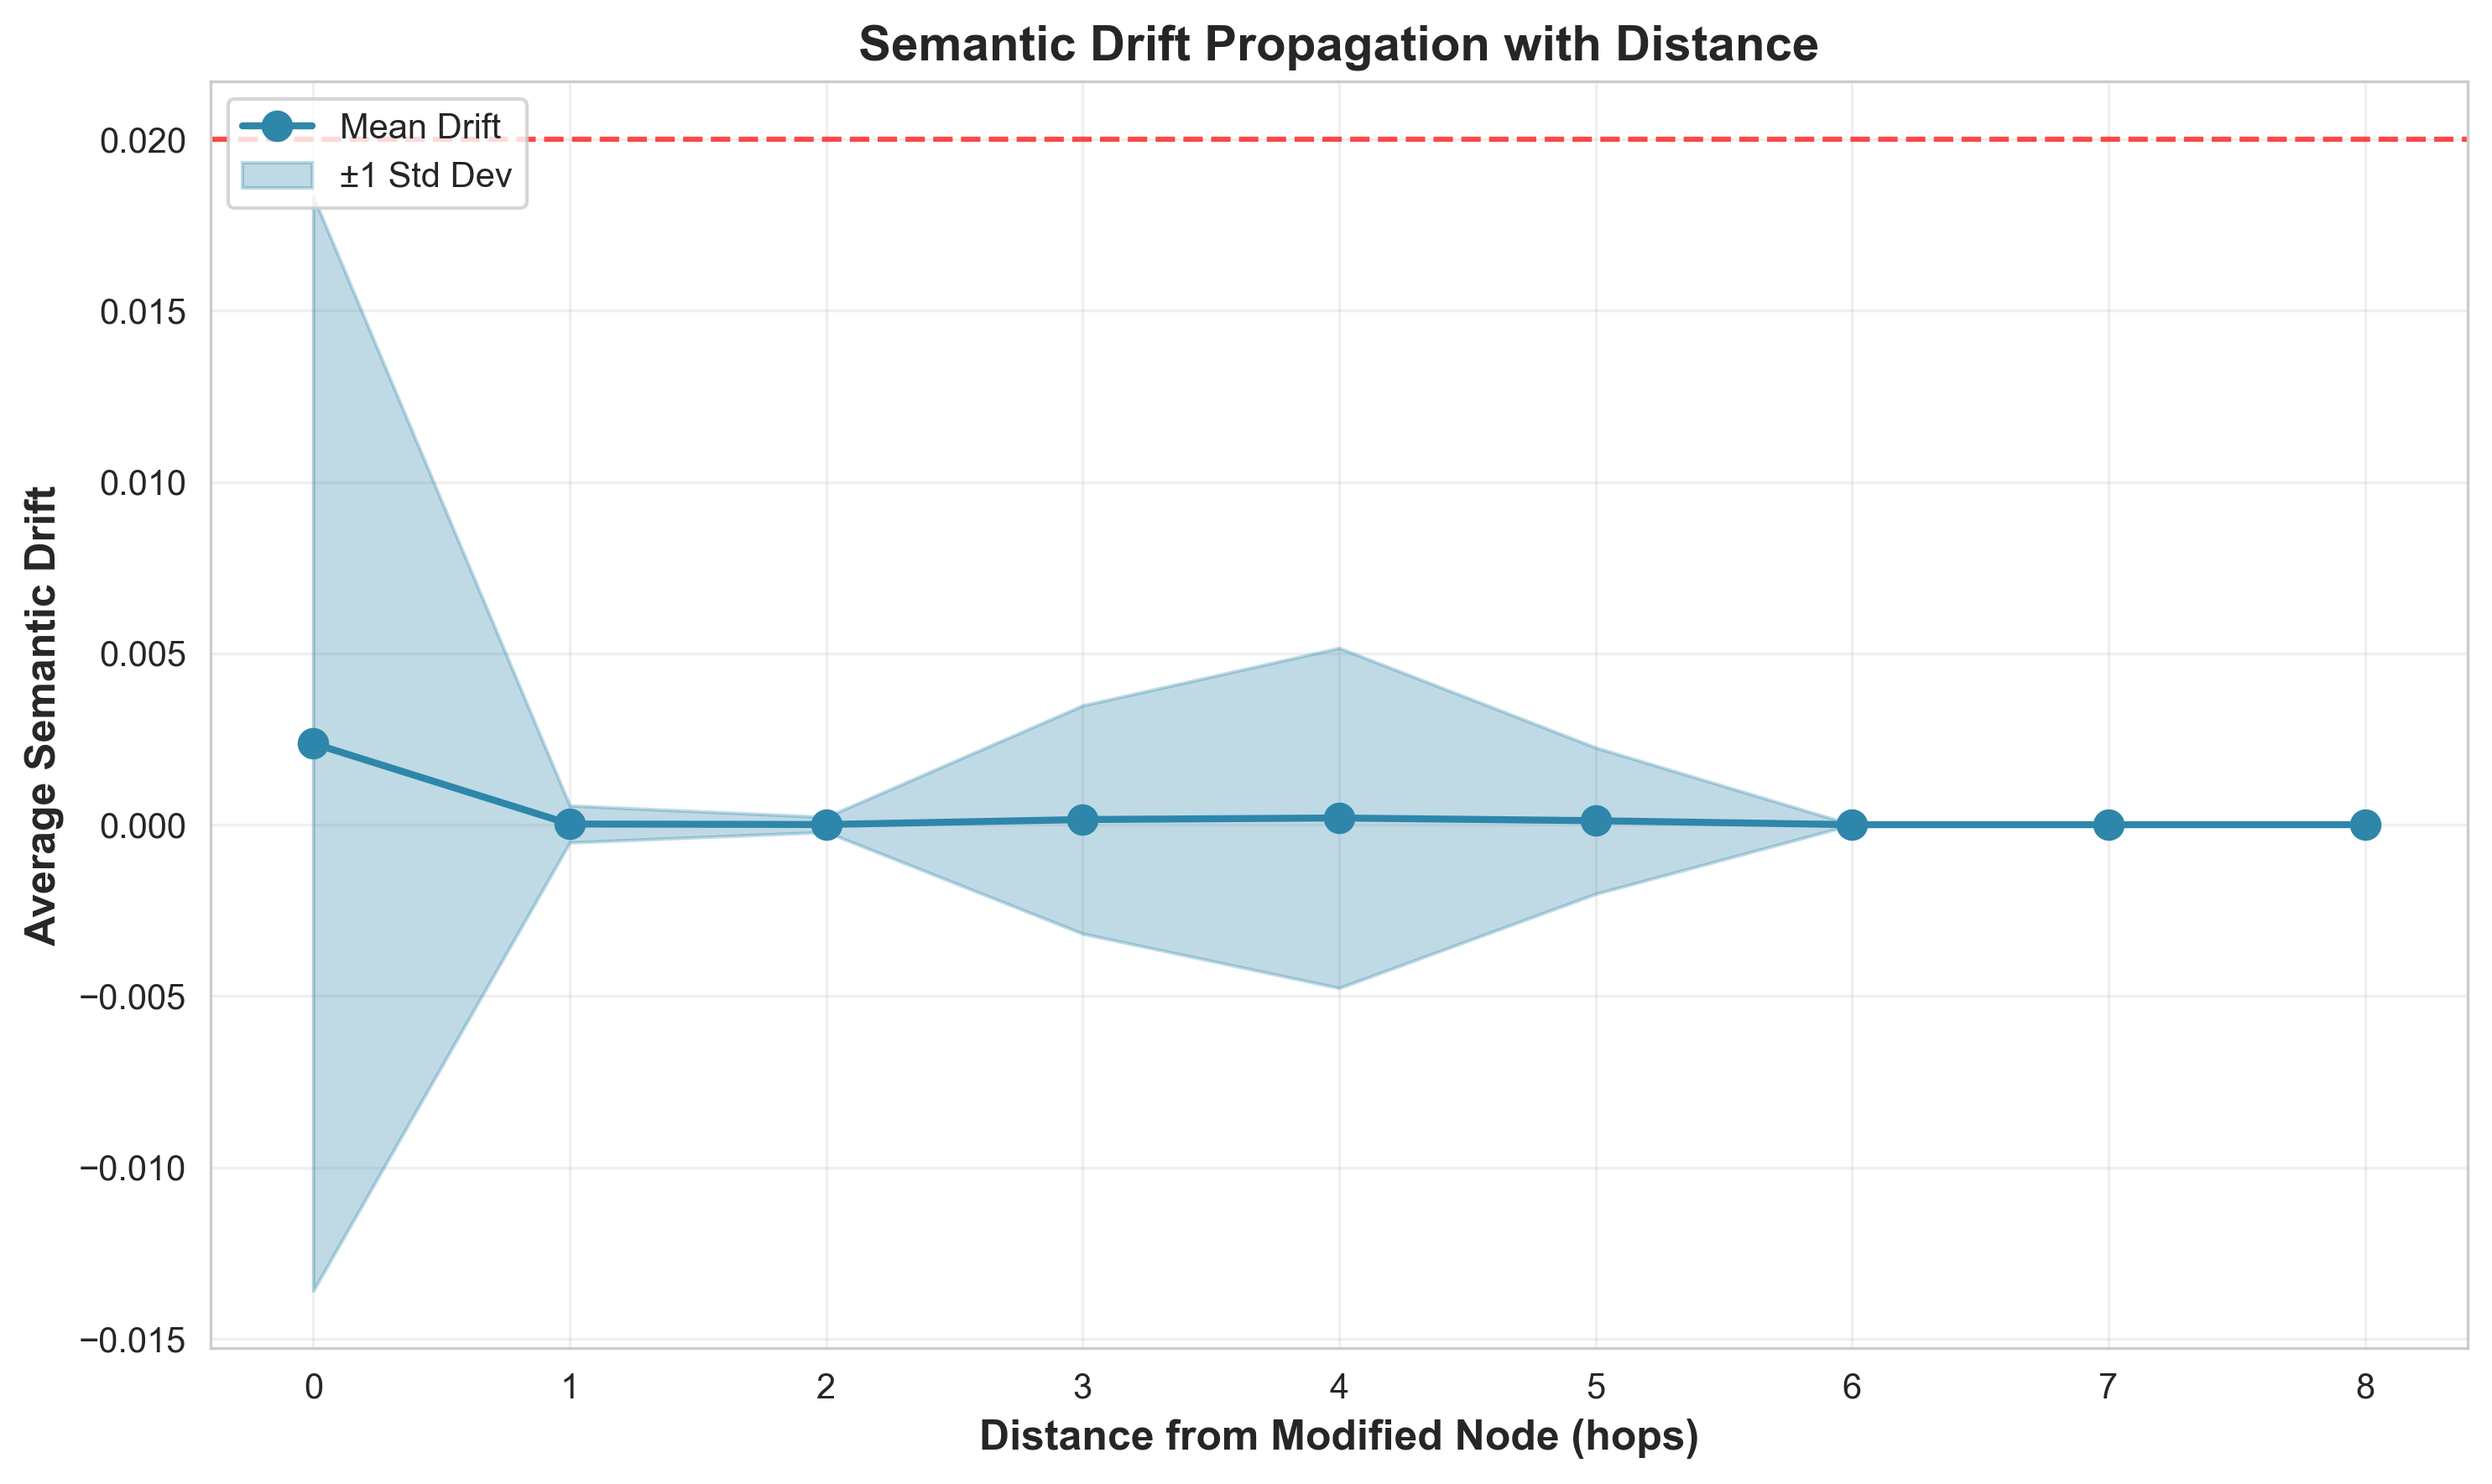

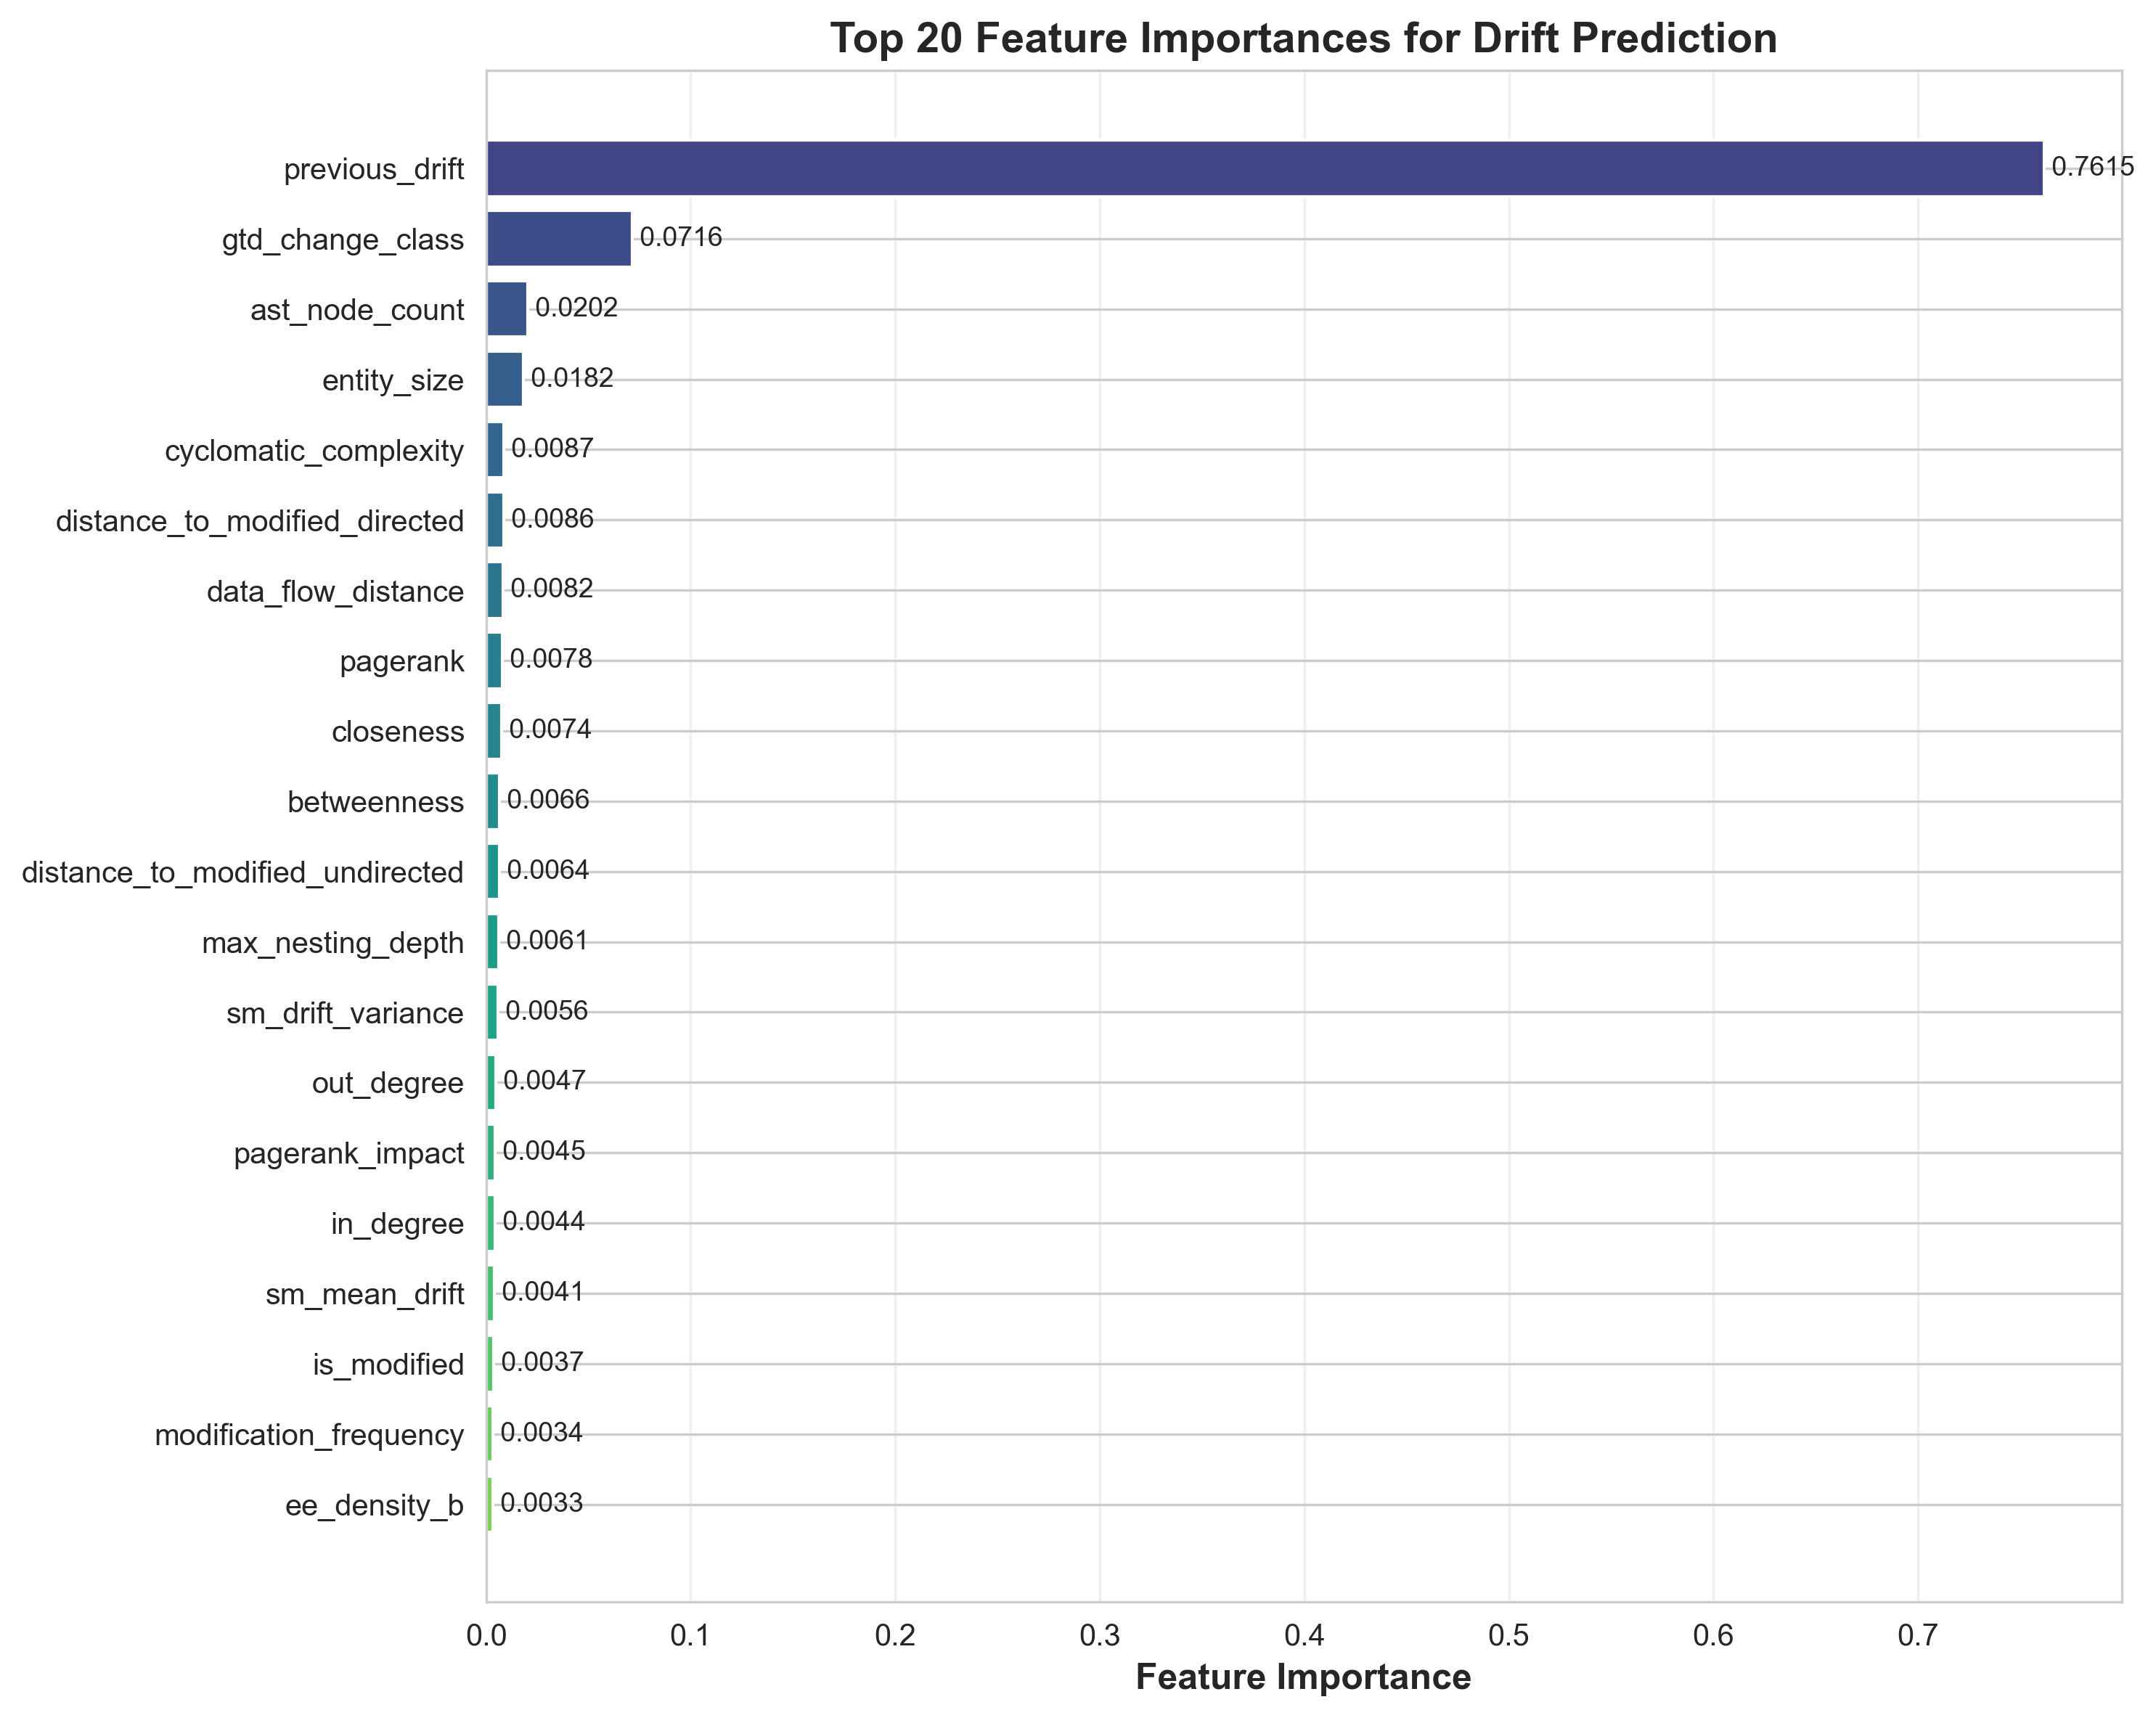

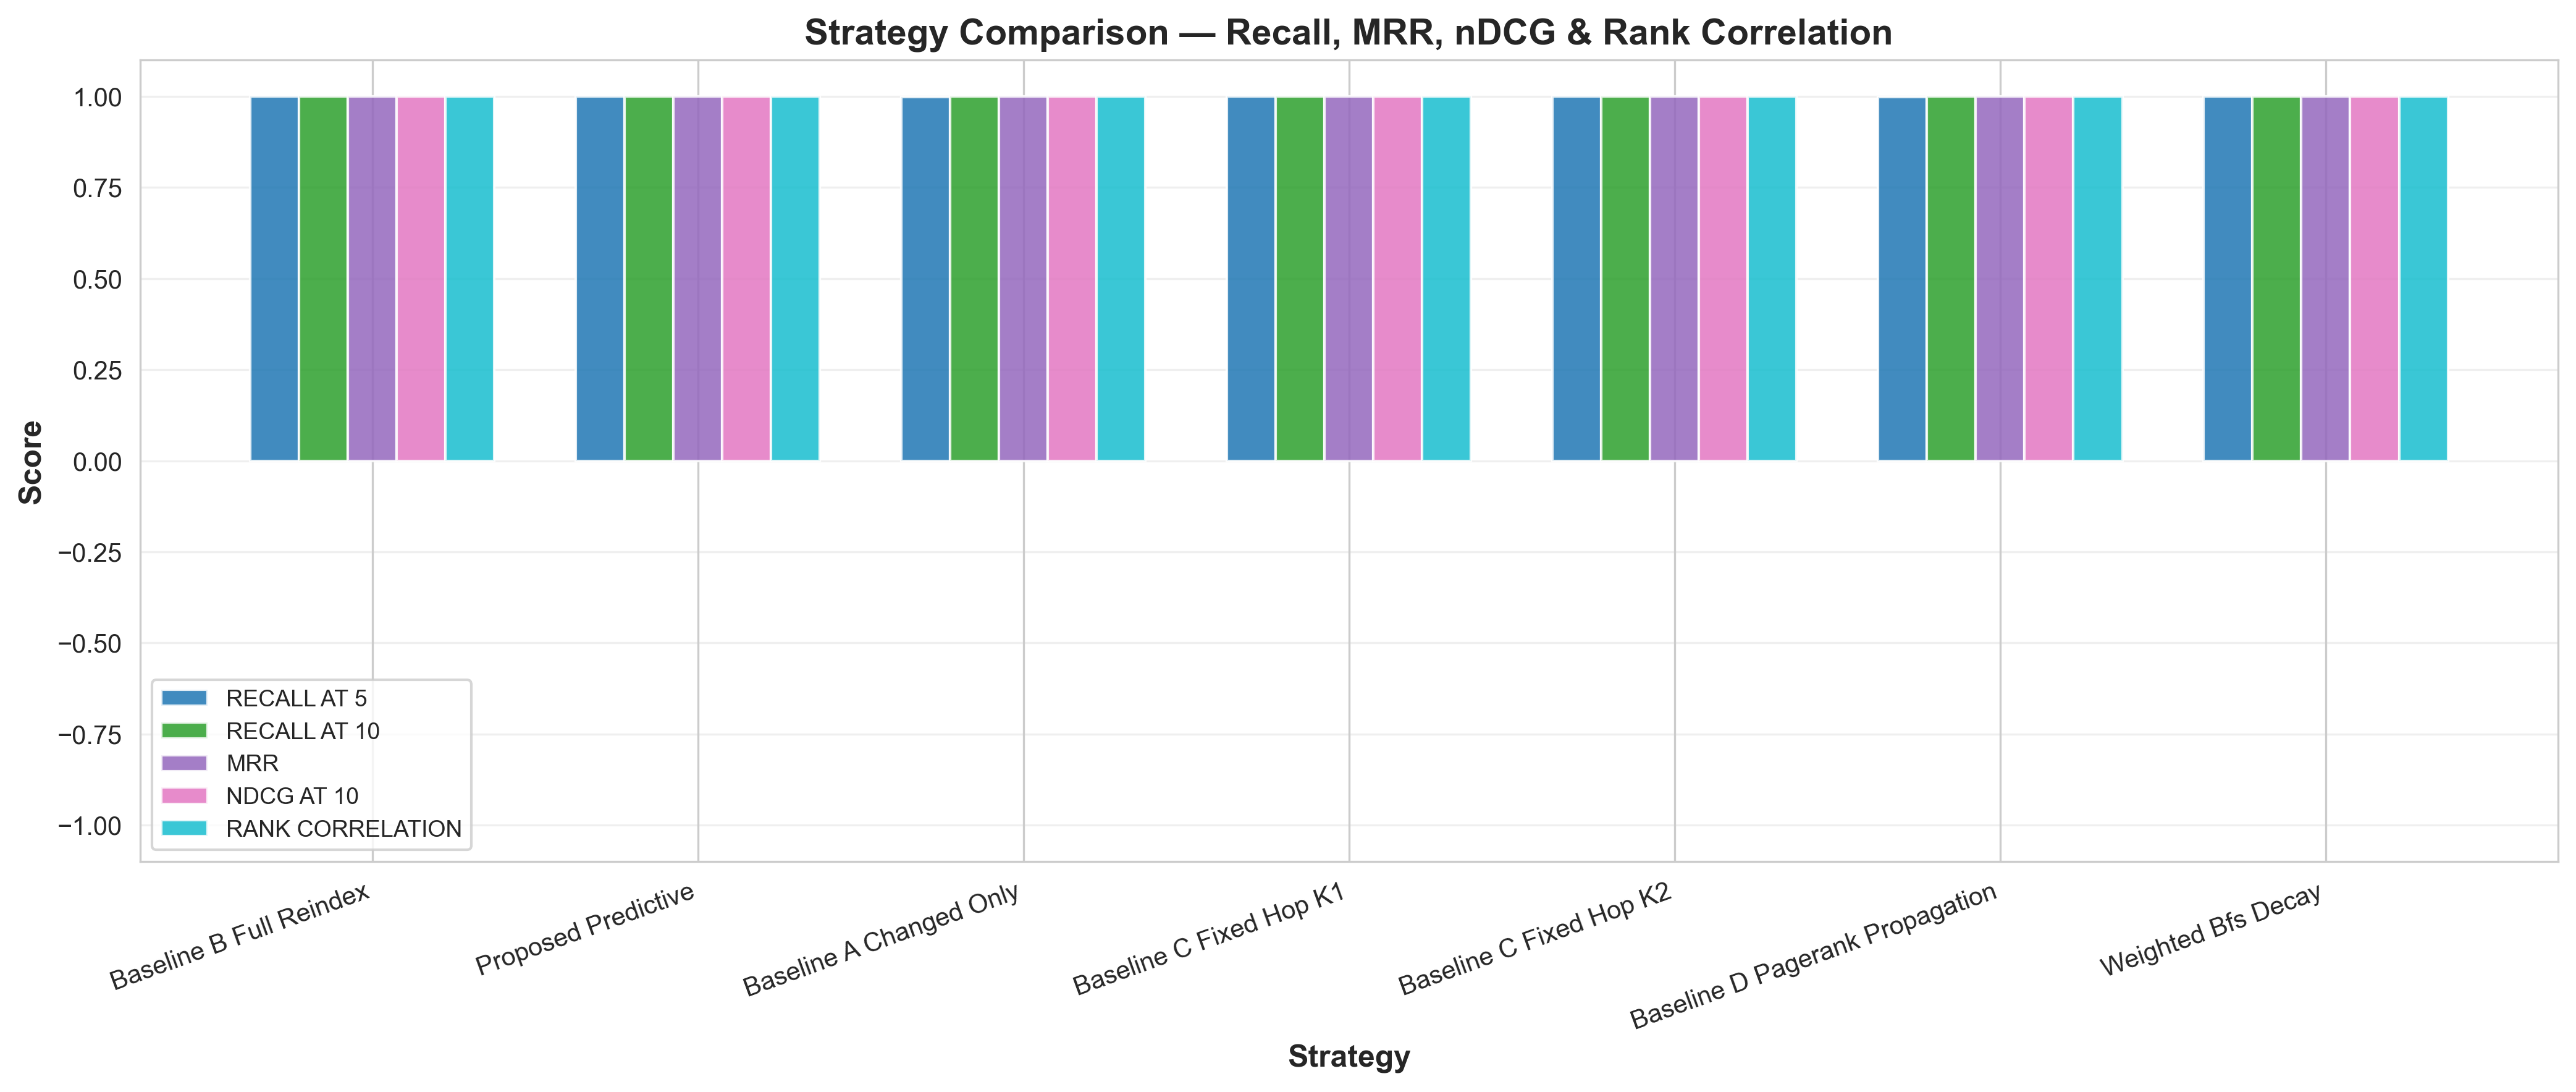

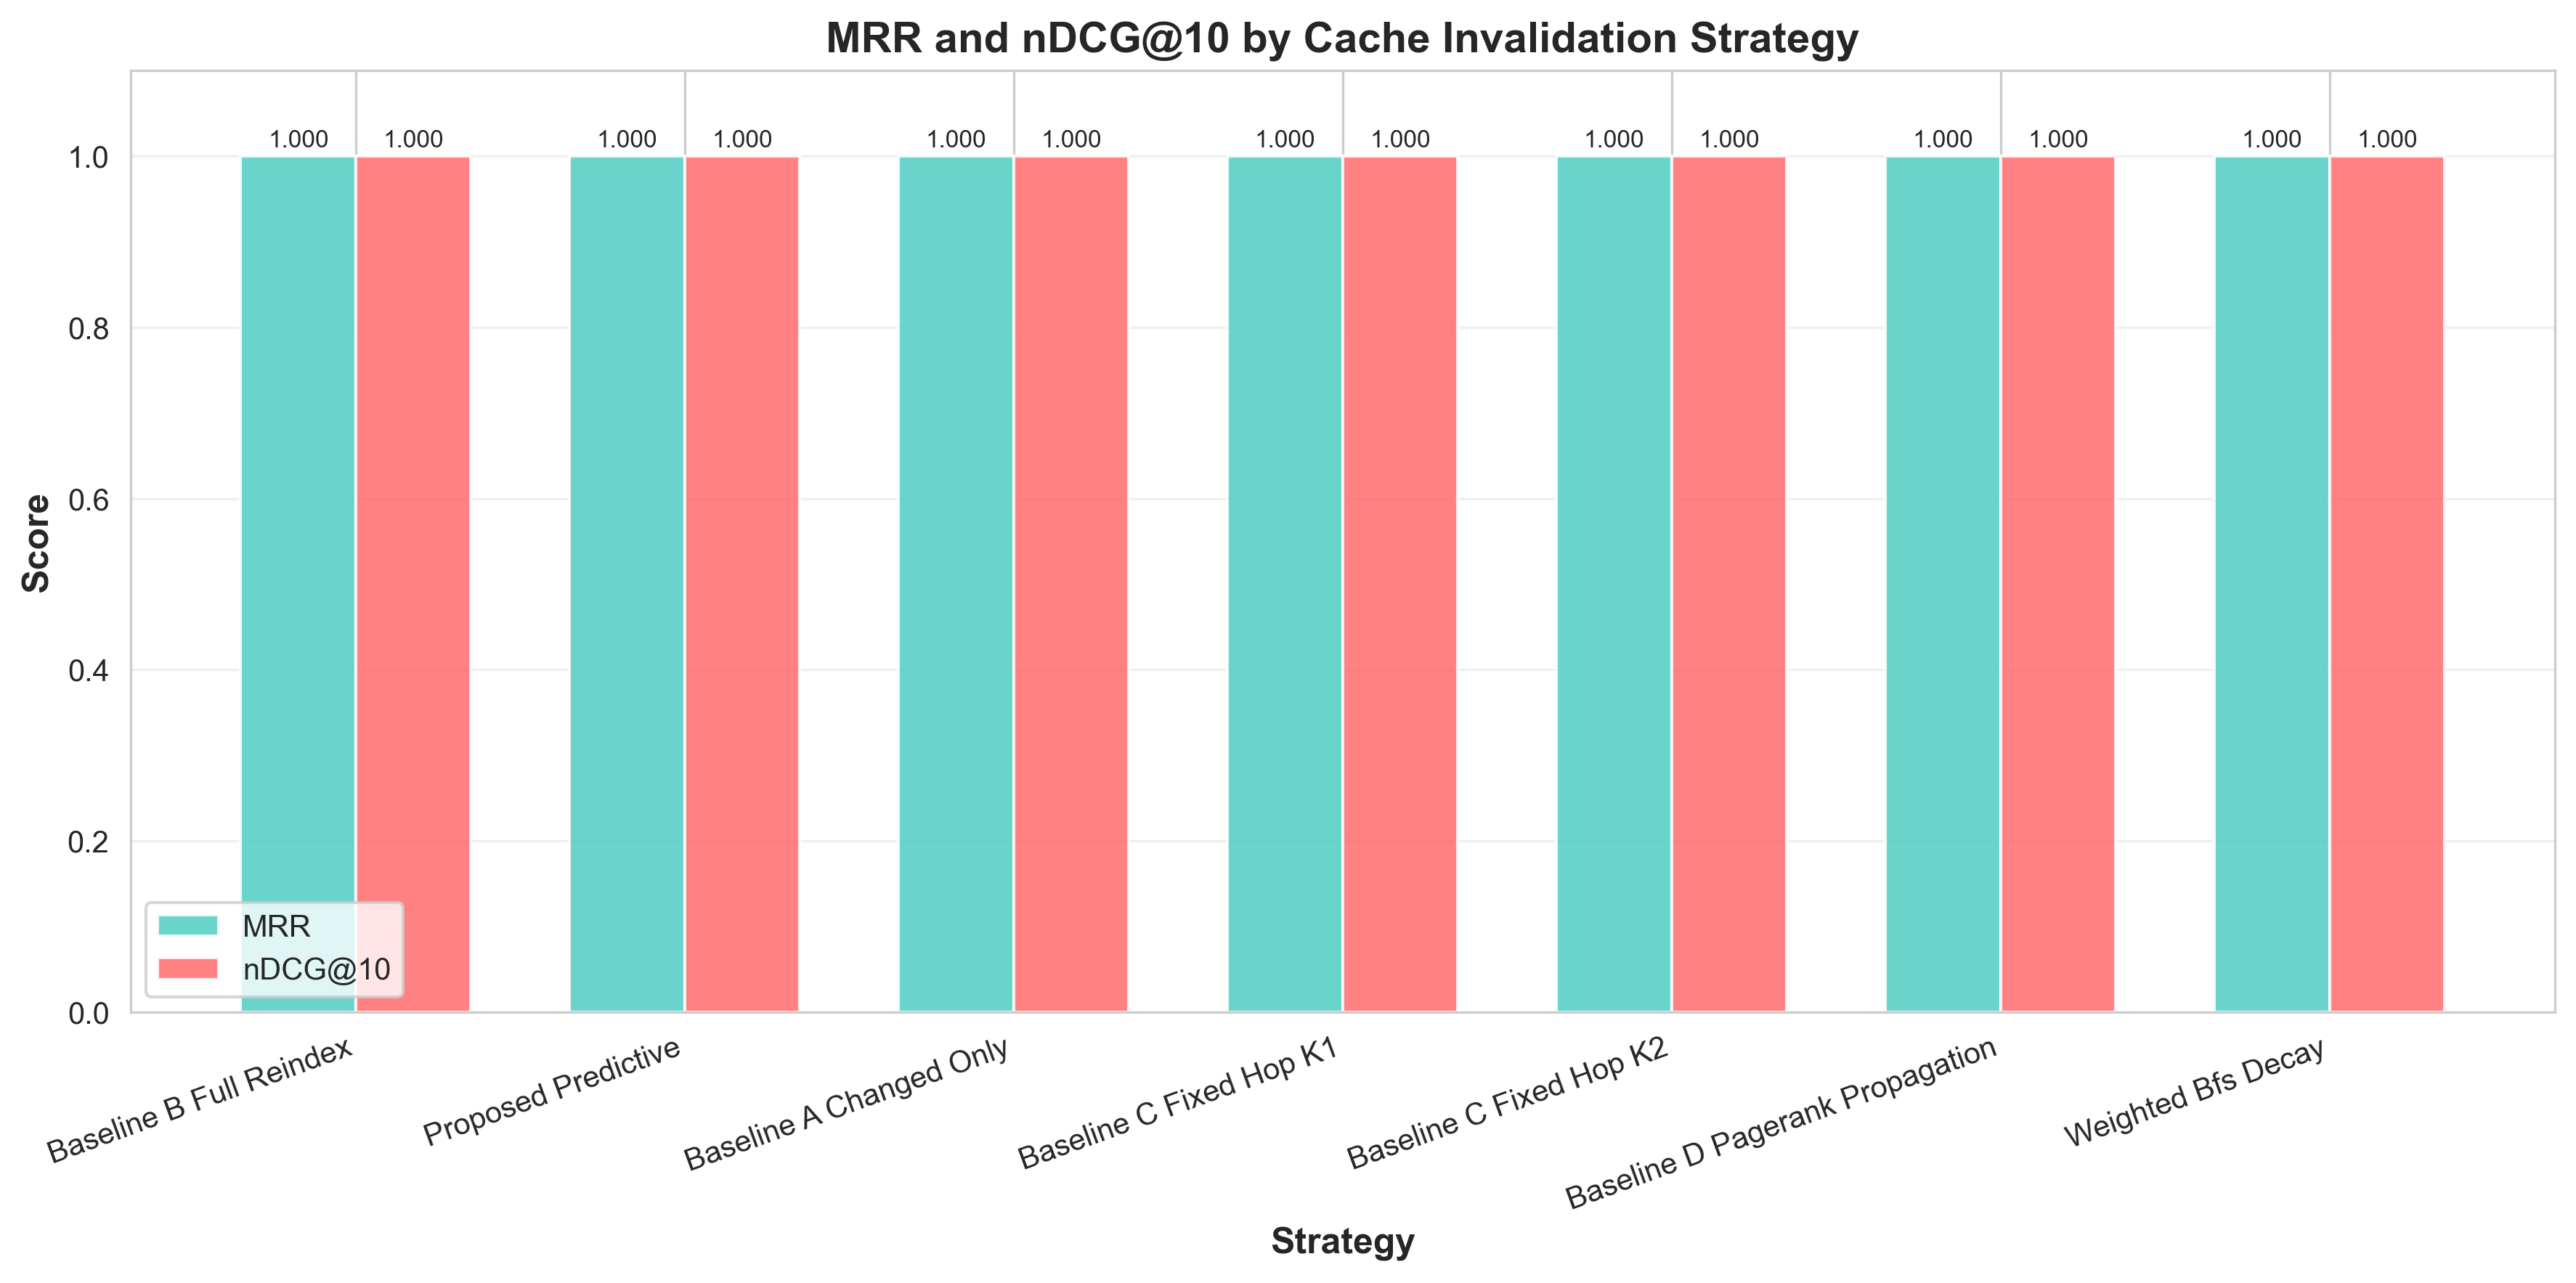

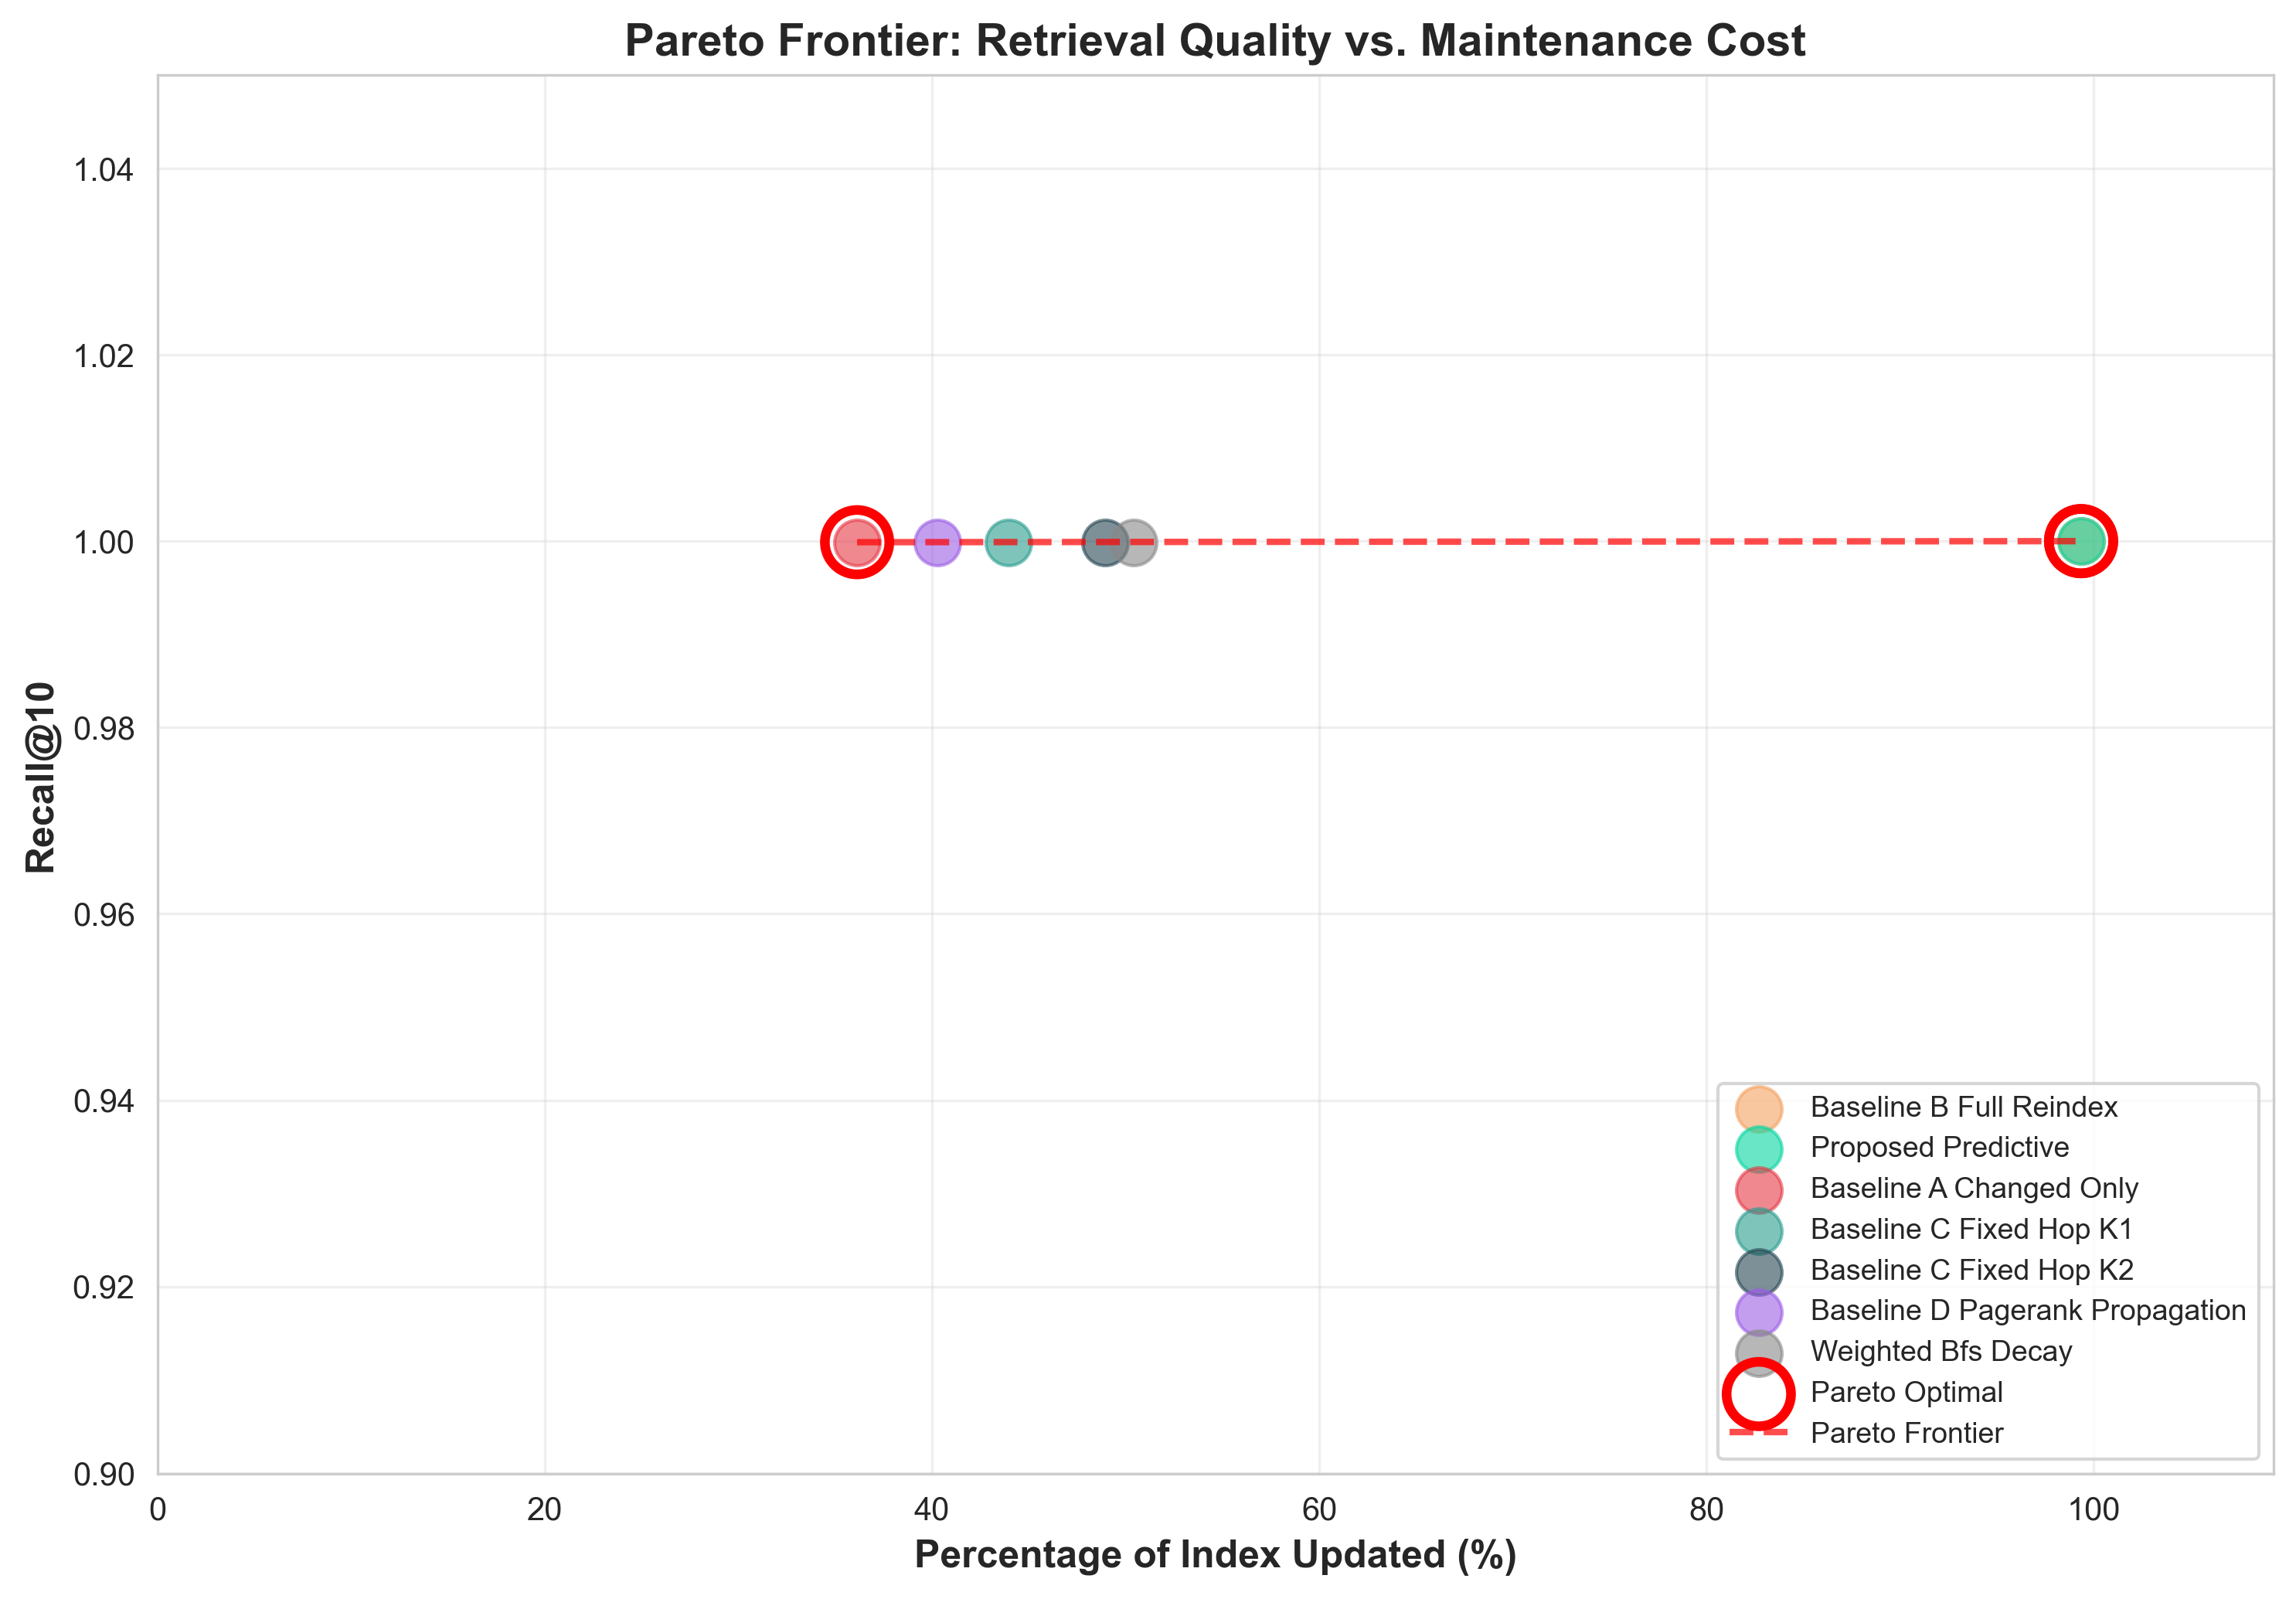

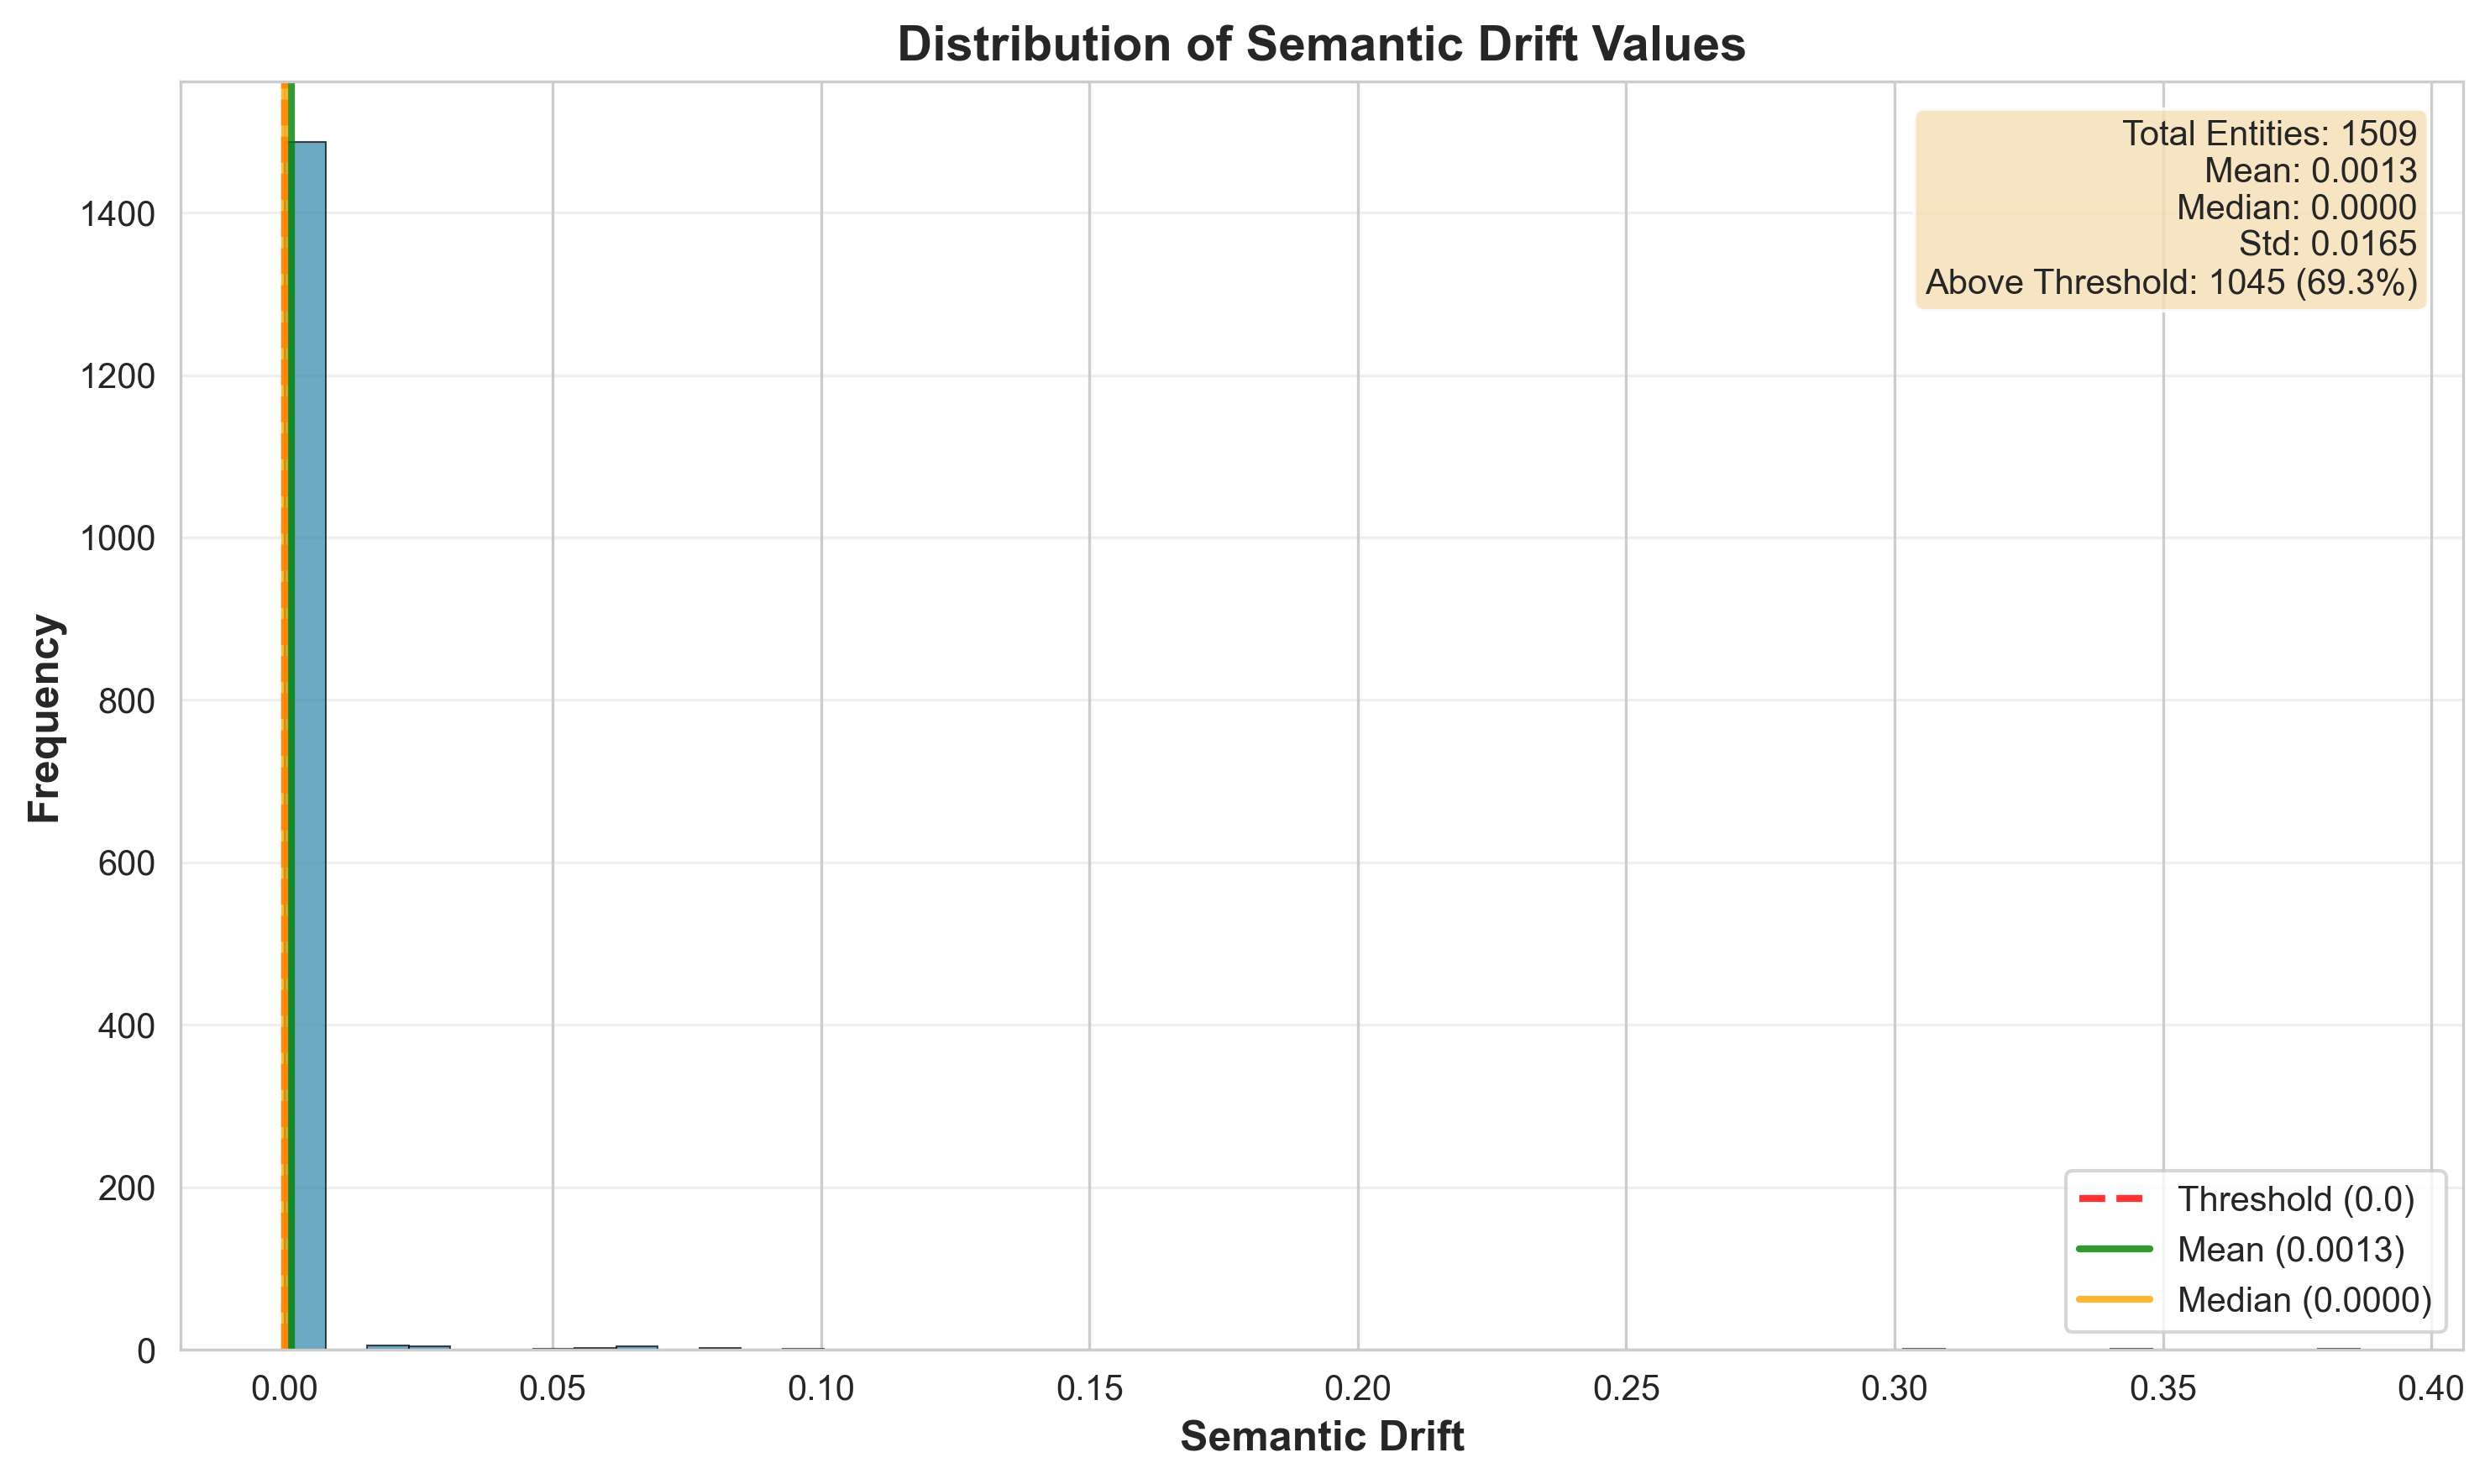

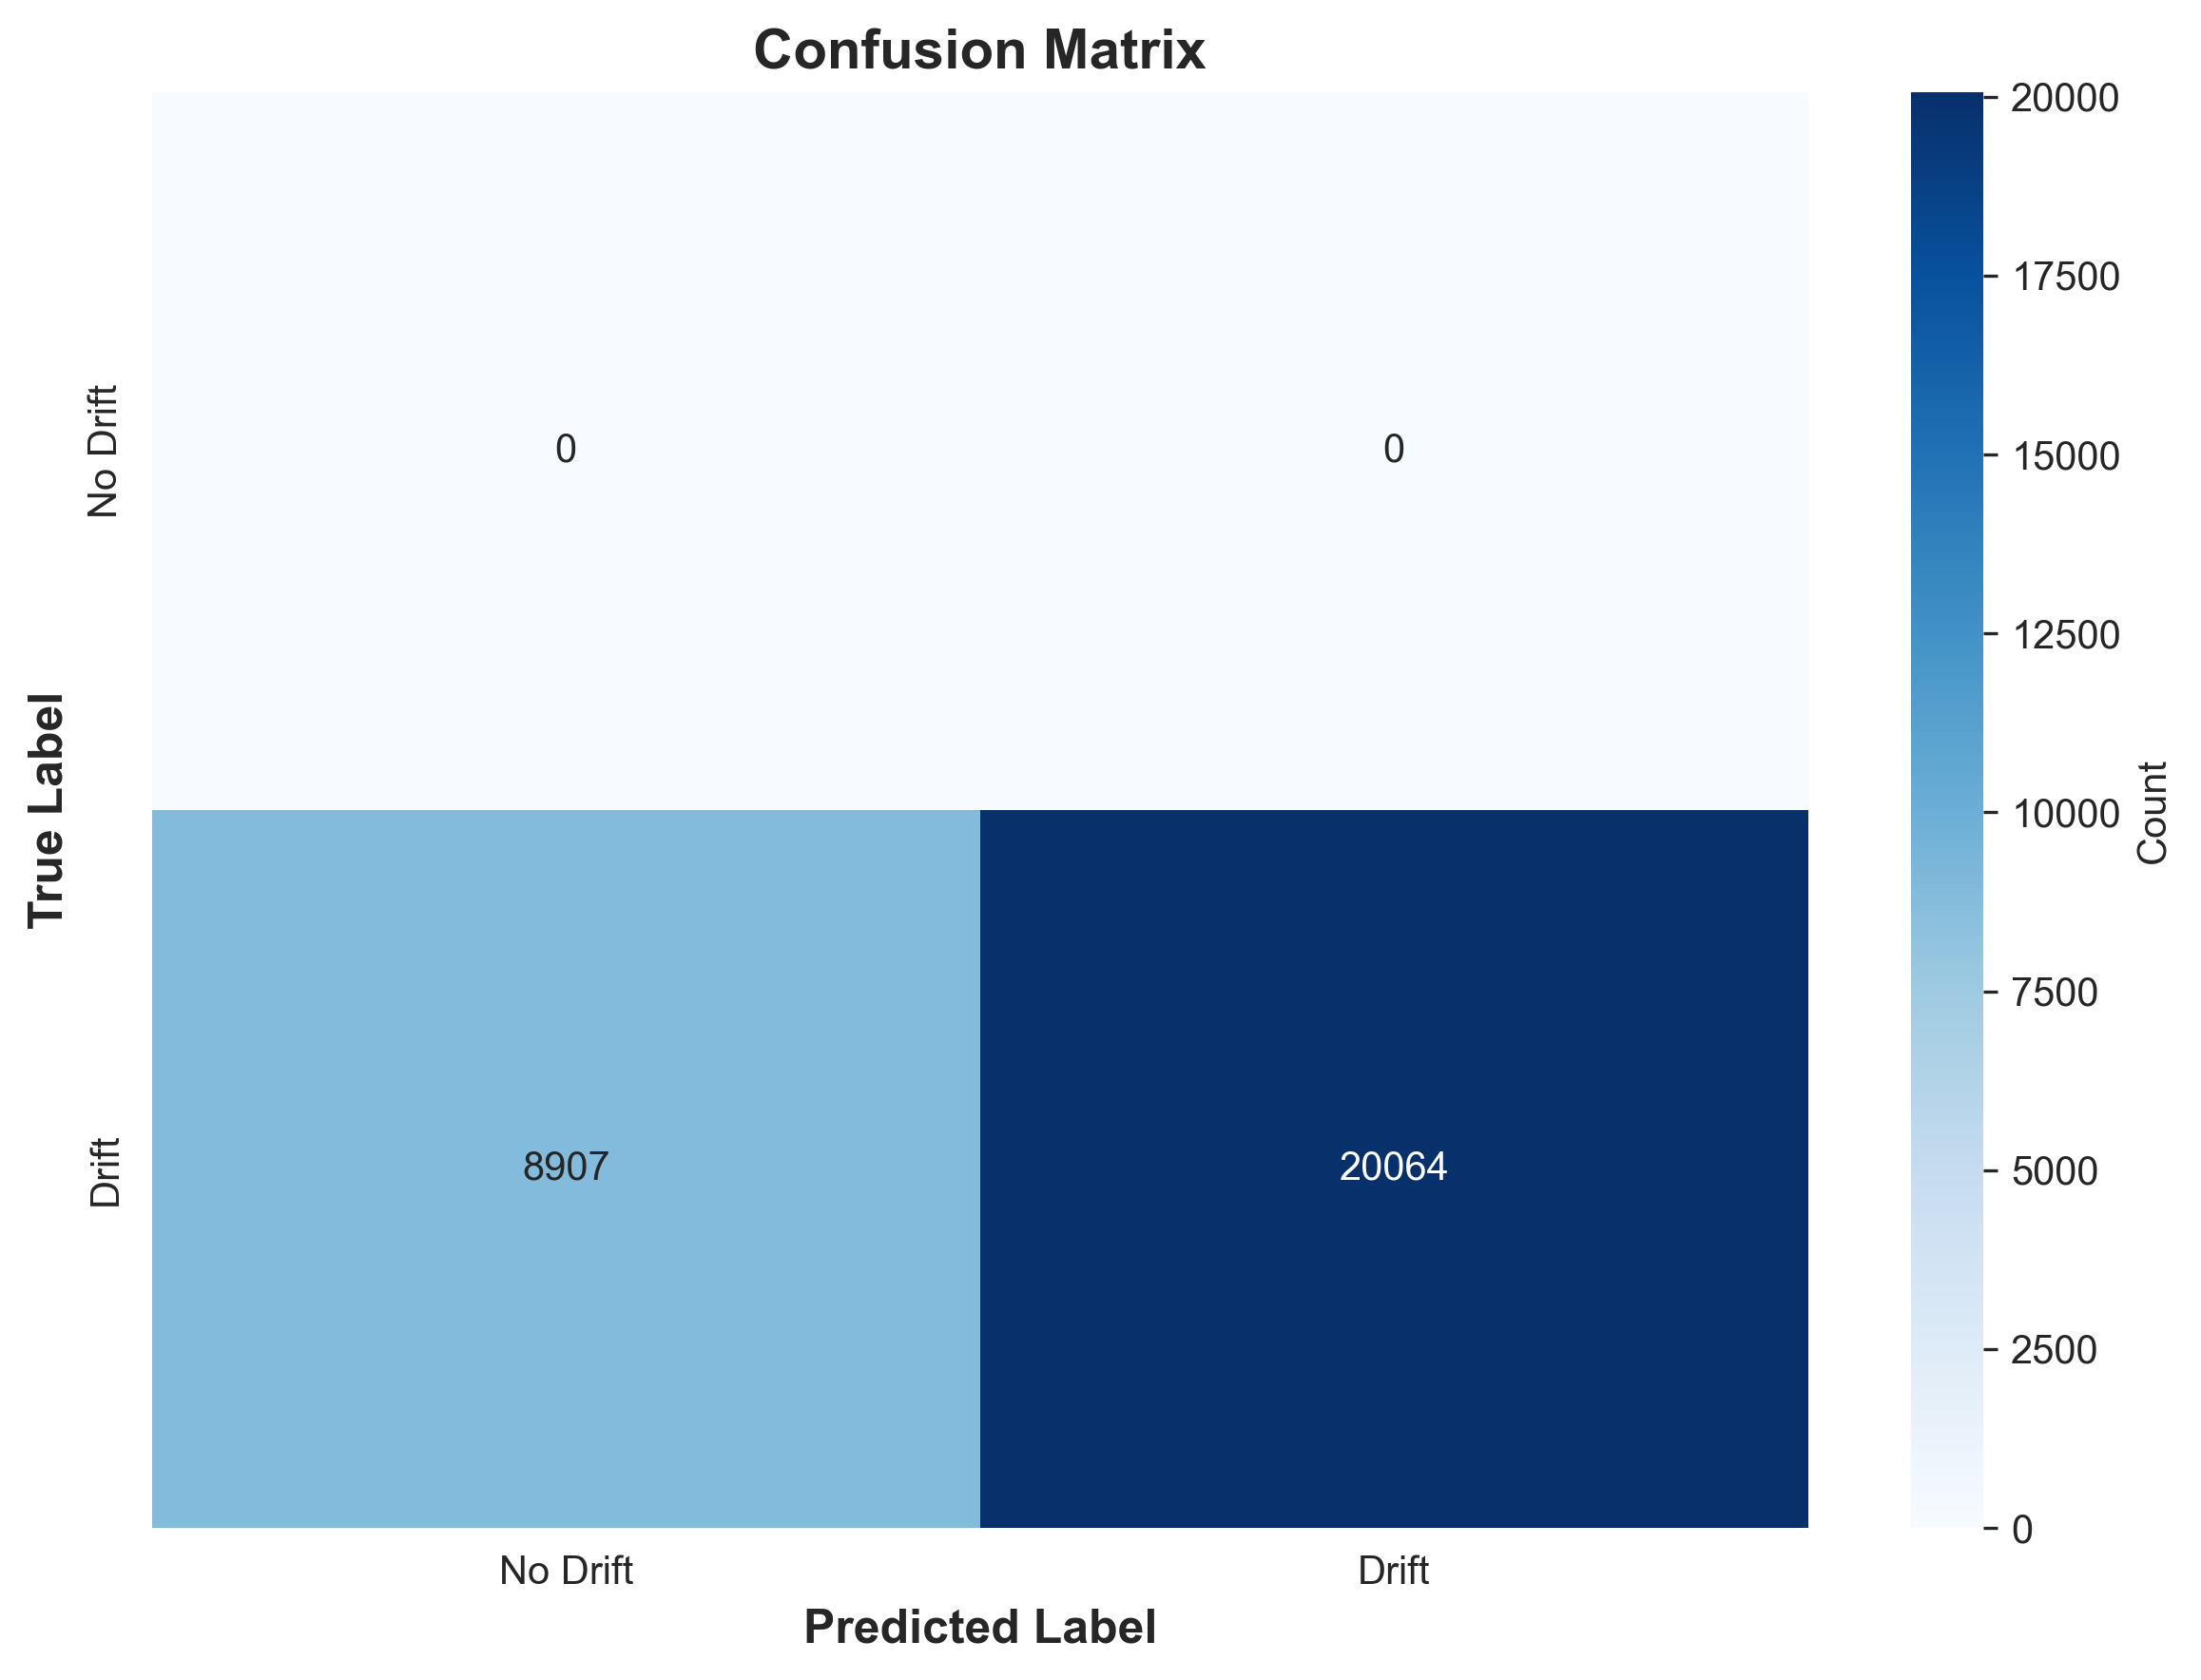

In [13]:
from IPython.display import Image, display

def show_plot(path: str):
    display(Image(filename=path))


results_for_viz = {
    "strategy_results": {name: row.to_dict() for name, row in averaged_results.iterrows()},
    "drift_by_distance": drift_by_distance,
}
feature_importance = predictor.get_feature_importance()

with timed("6_visualize", "plots"):
    plot_paths = []

    if drift_by_distance:
        plot_paths.append(visualizer.plot_drift_decay(drift_by_distance))

    if feature_importance:
        plot_paths.append(visualizer.plot_feature_importance(feature_importance))

    plot_paths.append(visualizer.plot_strategy_comparison(results_for_viz["strategy_results"]))
    plot_paths.append(visualizer.plot_ranking_metrics(results_for_viz["strategy_results"]))

    pareto_df = evaluator.compute_pareto_frontier(results_for_viz["strategy_results"],
                                                   recall_metric=PRIMARY_RECALL_COL)
    cost_df = evaluator.compute_maintenance_cost(results_for_viz["strategy_results"])
    cost_df = cost_df.merge(
        pd.DataFrame([{"strategy": k, "recall": v.get(PRIMARY_RECALL_COL, 0)}
                      for k, v in results_for_viz["strategy_results"].items()]),
        on="strategy",
    )
    plot_paths.append(visualizer.plot_pareto_frontier(pareto_df, cost_df))

    all_drifts_flat = {}
    for d in drifts_history.values():
        all_drifts_flat.update(d)
    if all_drifts_flat:
        plot_paths.append(visualizer.plot_drift_distribution(all_drifts_flat, threshold))

    if all_predictions and all_labels:
        plot_paths.append(visualizer.plot_confusion_matrix(np.array(all_labels), np.array(all_predictions)))

for p in plot_paths:
    show_plot(p)

In [14]:
with timed("6_visualize", "summary_report"):
    report_path = visualizer.generate_summary_report({
        "feature_importance": feature_importance or {},
        "strategy_results": results_for_viz["strategy_results"],
    })

print(Path(report_path).read_text())
print(f"\nAll plots + summary report saved under: {results_dir}")

PREDICTIVE SEMANTIC CACHE INVALIDATION - EXPERIMENT SUMMARY

TOP 10 FEATURE IMPORTANCES
--------------------------------------------------------------------------------
1. previous_drift: 0.7615
2. gtd_change_class: 0.0716
3. ast_node_count: 0.0202
4. entity_size: 0.0182
5. cyclomatic_complexity: 0.0087
6. distance_to_modified_directed: 0.0086
7. data_flow_distance: 0.0082
8. pagerank: 0.0078
9. closeness: 0.0074
10. betweenness: 0.0066

STRATEGY COMPARISON
--------------------------------------------------------------------------------

BASELINE_B_FULL_REINDEX
  Entities Updated: 658.4318181818181 / 662.75 (99.35%)
  Recall@5:          1.0000
  Recall@10:         1.0000
  MRR:               1.0000
  nDCG@10:           1.0000
  Rank Correlation:  1.0000
  Evaluation Time:   0.0000s

PROPOSED_PREDICTIVE
  Entities Updated: 658.4318181818181 / 662.75 (99.35%)
  Recall@5:          1.0000
  Recall@10:         1.0000
  MRR:               1.0000
  nDCG@10:           1.0000
  Rank Correlation

## Timing summary

Everything timed above, broken down by stage and sub-step, sorted by total
time descending — this is what to look at to see where the pipeline actually
spends its time.

In [15]:
by_stage = timing_table(group_cols=("stage",))
by_stage

,stage,calls,total_seconds,mean_seconds
0,2_parse_embed,600,1189.311222,1.982185
1,3_drift_features,597,350.529169,0.587151
2,5_evaluate,396,134.393293,0.339377
3,0_setup,2,14.019605,7.009802
4,6_visualize,2,2.509154,1.254577
5,4_train,5,1.148611,0.229722
6,1_harvest,1,0.094431,0.094431


In [16]:
by_substage = timing_table(group_cols=("stage", "substage"))
by_substage

,stage,substage,calls,total_seconds,mean_seconds
0,2_parse_embed,parse,150,793.136197,5.287575
1,2_parse_embed,embed,150,377.539731,2.516932
2,3_drift_features,extract_features,149,321.809961,2.159798
3,5_evaluate,strategy::baseline_c_fixed_hop_k2,44,58.403939,1.327362
4,5_evaluate,strategy::baseline_c_fixed_hop_k1,44,58.219468,1.323170
5,3_drift_features,modified_entities,149,24.669250,0.165565
6,2_parse_embed,checkout,150,15.617500,0.104117
7,0_setup,clone_repo,1,14.017630,14.017630
8,5_evaluate,generate_queries,44,7.768665,0.176561
9,3_drift_features,gtd,149,3.899114,0.026169


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_stage["stage"][::-1], by_stage["total_seconds"][::-1])
ax.set_xlabel("Total seconds")
ax.set_title("Time per pipeline stage")
plt.tight_layout()
plt.show()

grand_total = sum(t["seconds"] for t in TIMINGS)
print(f"\nTotal measured wall-clock time: {grand_total:.2f}s ({grand_total/60:.1f} min)")


Total measured wall-clock time: 1692.01s (28.2 min)
